## Imports

In [79]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras import regularizers
from abc import ABC, abstractmethod

RANDOM_SEED = 42

## Generate the Data Matrix and the Label vector

In [80]:
D_list = []
y_list = []

for subject_id in range(1, 41):
    folder = f'data/s{subject_id}'
    for img_id in range(1, 11):
        img_path = os.path.join(folder, f'{img_id}.pgm')
        img = Image.open(img_path)
        img_arr = np.asarray(img).flatten()
        D_list.append(img_arr)
        y_list.append(subject_id)

D = np.array(D_list)
y = np.array(y_list)
print("Data Matrix Shape: ", D.shape)
print("Label Vector Shape: ", y.shape)

Data Matrix Shape:  (400, 10304)
Label Vector Shape:  (400,)


## Split the Dataset into Training and Test sets

In [81]:
"""
From the Data Matrix D400x10304 keep the odd rows for training and the even rows for
testing. This will give you 5 instances per person for training and 5 instances per person
for testing
"""
X_train_lst = []
X_test_lst = []
y_train_lst = []
y_test_lst = []

for row in range(D.shape[0]):
    if row % 2 == 1:
        X_train_lst.append(D[row])
        y_train_lst.append(y[row])
    else:
        X_test_lst.append(D[row])
        y_test_lst.append(y[row])

X_train = np.array(X_train_lst)
X_test = np.array(X_test_lst)
y_train = np.array(y_train_lst)
y_test = np.array(y_test_lst)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200, 10304)
(200,)
(200, 10304)
(200,)


## PCA Implementation

In [82]:
class PCA:
    def __init__(self, cache_dir=None):
        self.mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.explained_variance = None
        self.cumulative_variance = None
        self.cache_dir = cache_dir

        # If a cache path is given, try to load saved eigenvalues/vectors
        if cache_dir:
            try:
                self.eigenvalues = np.load(os.path.join(cache_dir, 'eigenvalues.npy'))
                self.eigenvectors = np.load(os.path.join(cache_dir, 'eigenvectors.npy'))
                self.mean = np.load(os.path.join(cache_dir, 'mean.npy'))
                # Calculate explained variance and cumulative variance
                self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
                self.cumulative_variance = np.cumsum(self.explained_variance)
                print("Loaded PCA data from cache.")
            except FileNotFoundError:
                print("PCA cache not found. Will compute and save later.")

    def fit(self, X):
        if self.eigenvalues is not None and self.eigenvectors is not None and self.mean is not None:
            return # already computed

        # Mean-center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Calculate covariance Matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute eigenvalues and eigenvectors (sorted ascendingly)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Make them sorted in descending order
        self.eigenvalues = eigenvalues[::-1]
        self.eigenvectors = eigenvectors[:, ::-1]

        # Calculate explained variance and cumulative variance
        self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.explained_variance)

        # Save to cache if specified
        if self.cache_dir:
            # Ensure the directory exists
            os.makedirs(self.cache_dir, exist_ok=True)
            np.save(os.path.join(self.cache_dir, 'eigenvalues.npy'), self.eigenvalues)
            np.save(os.path.join(self.cache_dir, 'eigenvectors.npy'), self.eigenvectors)
            np.save(os.path.join(self.cache_dir, 'mean.npy'), self.mean)
    
    def transform(self, X, threshold): 
        if self.eigenvectors is None:
            raise Exception("Must call fit() before transform().")
        
        n_components = np.searchsorted(self.cumulative_variance, threshold) + 1
        pcs = self.eigenvectors[:, :n_components]
        X_centered = X - self.mean
        return np.dot(X_centered, pcs), n_components
    
    def inverse_transform(self, X_pca, n_components):
        if self.eigenvectors is None:
            raise Exception("Must call fit() before inverse_transform().")
        pcs = self.eigenvectors[:, :n_components]
        return np.dot(X_pca, pcs.T) + self.mean 


In [83]:
def visualize_faces(X, pca, n_faces=5, pca_threshold=0.9):
    # Randomly choose n_faces indices from the training data
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(X.shape[0], size=n_faces, replace=False)
    sampled_faces = X[indices]

    sampled_faces_pca, n_components = pca.transform(sampled_faces, pca_threshold)

    # Approximately reconstruct the faces back to the original space
    reconstructed_faces = pca.inverse_transform(sampled_faces_pca, n_components)

    fig, axes = plt.subplots(2, n_faces, figsize=(3 * n_faces, 6))

    fig.suptitle(f"Original (Top) vs Reconstructed (Bottom)\nPCA Threshold = {pca_threshold * 100:.1f}%", weight='bold', fontsize=16)

    for i in range(n_faces):
        # Top row: original faces
        axes[0, i].imshow(sampled_faces[i].reshape(112, 92), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(f"Original #{indices[i]}", fontsize=10)

        # Bottom row: reconstructed faces
        axes[1, i].imshow(reconstructed_faces[i].reshape(112, 92), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f"Reconstructed #{indices[i]}", fontsize=10)

    fig.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

Loaded PCA data from cache.
at Alpha = 0.8, Components Retained (Dimensionality) = 37


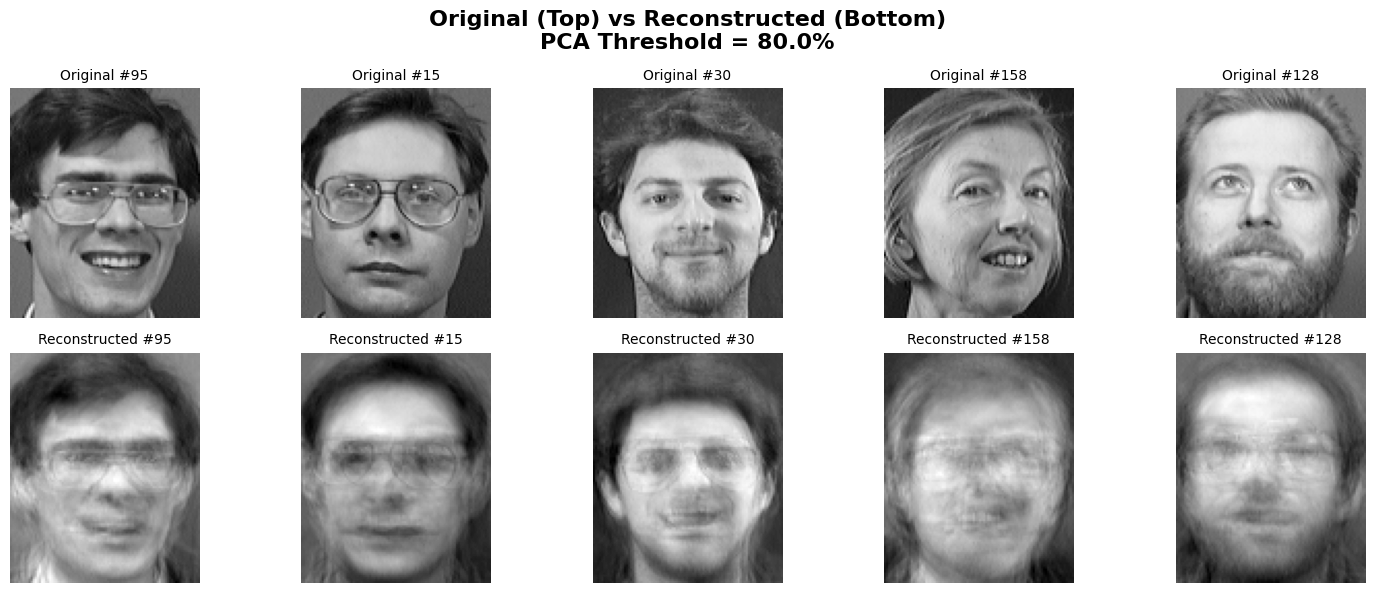

at Alpha = 0.85, Components Retained (Dimensionality) = 53


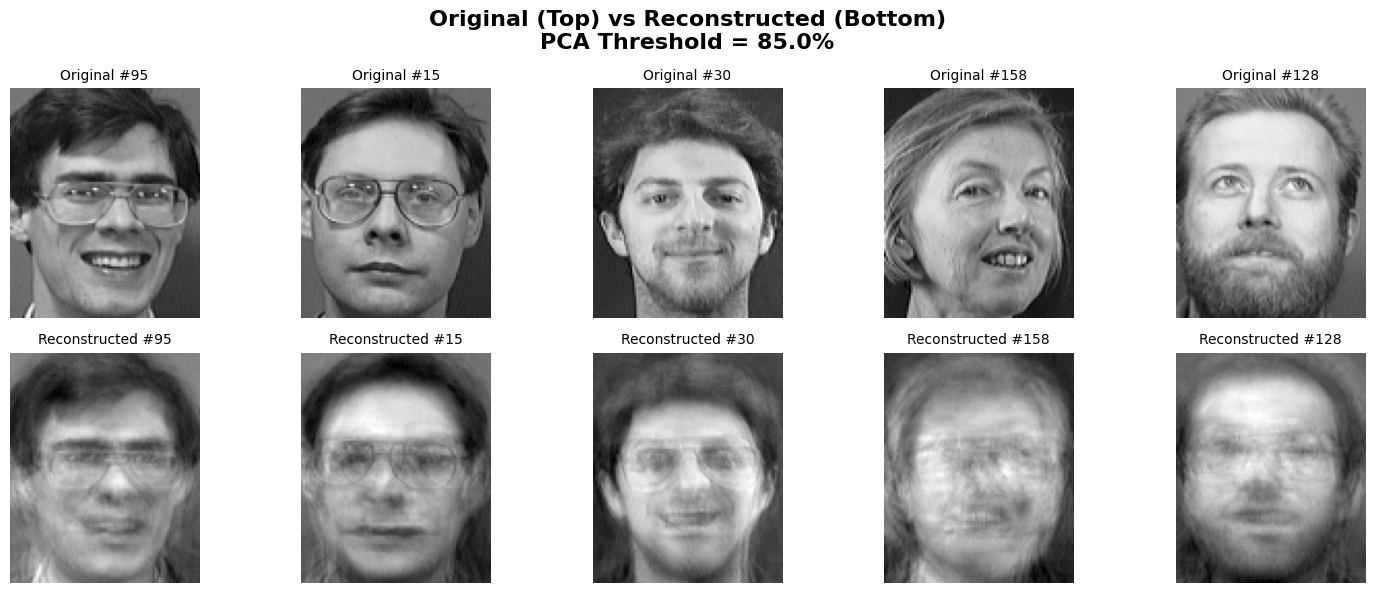

at Alpha = 0.9, Components Retained (Dimensionality) = 77


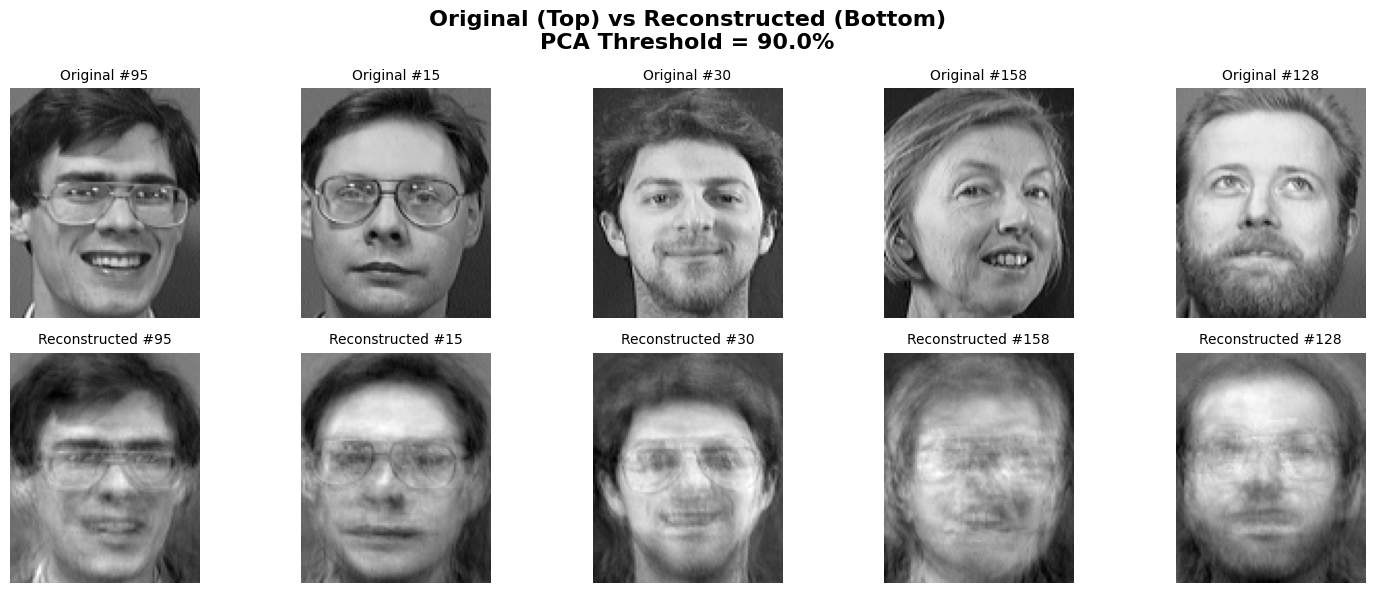

at Alpha = 0.95, Components Retained (Dimensionality) = 116


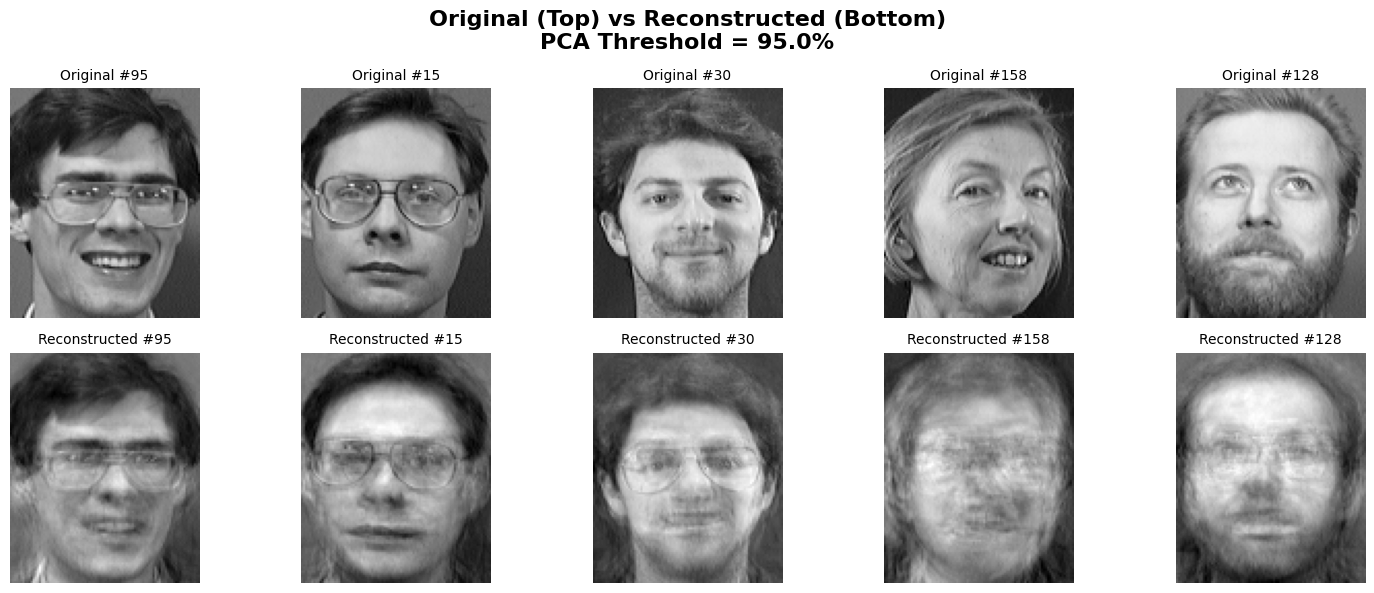

In [84]:
# Project the dataset into the reduced PCA subspace and report dimensionality 
# and visualize reconstructed samples for different thresholds
pca = PCA(cache_dir="pca_results")
pca.fit(X_train)

pca_projections = {} # will store X_train_pca, X_test_pca, n_components for each alpha

for alpha in [0.8, 0.85, 0.9, 0.95]:
    X_train_pca, n_components = pca.transform(X_train, alpha)
    X_test_pca, _ = pca.transform(X_test, alpha)
    pca_projections[alpha] = {
        "train": X_train_pca,
        "test": X_test_pca,
        "n_components": n_components
    }
    print(f"at Alpha = {alpha}, Components Retained (Dimensionality) = {n_components}")
    visualize_faces(X_test, pca, n_faces=5, pca_threshold=alpha)

# K-Means Implementation

In [85]:
class DistanceStrategy(ABC):
    @abstractmethod
    def compute(self, X, centroids):
        pass

class EuclideanDistance(DistanceStrategy):
    def compute(self, X, centroids):
        return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

class ManhattanDistance(DistanceStrategy):
    def compute(self, X, centroids):
        return np.sum(np.abs(X[:, np.newaxis] - centroids), axis=2)

class CosineDistance(DistanceStrategy):
    def compute(self, X, centroids):
        # Normalize the vectors to make them unit vectors (keeppdims=True to make it 2D column vector not row vector)
        X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
        centroids_norm = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
        # cos(theta) = dot(X, Y) / (||X|| * ||Y||) since we normalized the vectors, we can skip the denominator     
        cosine_sim = np.dot(X_norm, centroids_norm.T)
        #cosine_sim = 1 when X and Y are the same, -1 when they are opposite 
        # Cosine distance = 1 - cosine similarity
        return 1 - cosine_sim

In [90]:
class KMeans:
    def __init__(self, n_clusters=40, max_iters=1000,random_initializations_limit=10, distance_strategy=EuclideanDistance):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        # self.random_seed = random_seed
        self.centroids = None #centroids for each cluster
        self.asigned_points = None #cluster id for each point
        self.cluster_to_label = None # cluster id to label mapping
        self.random_initializations_limit = random_initializations_limit
        self.distance_strategy = distance_strategy() if isinstance(distance_strategy, type) else distance_strategy
    def fit(self, X,):
        # np.random.seed(None)

        minimum_inertia = np.inf
        best_centroids = None
        best_asigned_points = None

        
        for i in range(self.random_initializations_limit):
            np.random.seed(i)
            # Initialize centroids randomly (it's better to select points instead of random values)
            selected_points_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
            centroids = X[selected_points_indices]
            asigned_points = np.zeros(X.shape[0], dtype=int)
            new_centroids = np.zeros(centroids.shape)

            for iter in range(self.max_iters):
                
                # Calculate distances from each point to each centroid (need rephrasing) )
                distances = self.distance_strategy.compute(X, centroids)

                # For each row (point) find the index of the minimum value along the columns , axis = 1 to compare distances horizontally
                asigned_points = np.argmin(distances, axis = 1)
                
                #Update centroids
                new_centroids = np.zeros(centroids.shape)
                for k in range(self.n_clusters):
                    cluster_points = X[asigned_points == k]
                    if len(cluster_points) > 0:
                        new_centroids[k] = cluster_points.mean(axis=0)
                    else:
                        new_centroids[k] = centroids[k]


                change = np.linalg.norm(centroids - new_centroids)
                if change < 1e-10:
                    break
                centroids = new_centroids 

            inertia = np.sum(np.min(distances, axis=1))
            if inertia < minimum_inertia:
                # print(f"New best inertia: {inertia} (iteration {i})")
                minimum_inertia = inertia
                best_centroids = centroids
                best_asigned_points = asigned_points
                
        self.centroids = best_centroids
        self.asigned_points = best_asigned_points

    def assign_labels_to_clusters(self, y_true):
        # print(f"true Labels for All Points: {y_true}")
        self.cluster_to_label = {}
        
        for cluster_id in range(self.n_clusters):

            # Find all indices of points assigned to this cluster
            indices = np.where(self.asigned_points == cluster_id)[0]

            # print(f"Indices for Cluster {cluster_id}: {indices}")

            if len(indices) == 0:
                continue  

            # Get true labels of these points
            true_labels = y_true[indices]
            label_counts = {}

            # print(f"Cluster {cluster_id}: True Labels = {true_labels}")

            # Count occurrences of each label
            for label in true_labels:
                if label in label_counts:
                    label_counts[label] += 1
                else:
                    label_counts[label] = 1

            # Find the label with the maximum count
            most_common_label = max(label_counts, key=label_counts.get)
            
            self.cluster_to_label[cluster_id] = most_common_label
    
    def kmeans_predict(self,X):
        # Compute distances between each point in X and each centroid
        distances =  self.distance_strategy.compute(X, self.centroids)

        # Assign each point to the nearest cluster
        assigned_clusters = np.argmin(distances, axis=1)

        # Map the assigned clusters to the corresponding labels
        predicted_labels = np.array([self.cluster_to_label[cluster_id] for cluster_id in assigned_clusters])
        return predicted_labels

In [91]:
def evaluate_model(X_train, y_train, X_test, y_test, n_clusters=40,alpha=0.9, random_initializations_limit = 100, distance_strategy=EuclideanDistance):
    # get PCs and transform the data
    pca = PCA(cache_dir="pca_results")
    pca.fit(X_train)
    X_pca, _ = pca.transform(X_train, threshold=alpha)
    
    # Initialize KMeans with the specified distance strategy and fit the model
    kmeans = KMeans(n_clusters=n_clusters, random_initializations_limit=random_initializations_limit, distance_strategy=distance_strategy)
    kmeans.fit(X_pca)
    kmeans.assign_labels_to_clusters(y_train)
    
    # Transform the test data using the same PCA transformation and then predict labels
    X_test_pca, _ = pca.transform(X_test, threshold=alpha)
    y_pred = kmeans.kmeans_predict(X_test_pca)

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_test) * 100
    # print(f"Accuracy: {accuracy:.2f}%")
    
    return accuracy,y_pred

Loaded PCA data from cache.
Accuracy for K=20 and Alpha=0.8: 45.50%
Loaded PCA data from cache.
Accuracy for K=40 and Alpha=0.8: 64.50%
Loaded PCA data from cache.
Accuracy for K=60 and Alpha=0.8: 75.00%


Loaded PCA data from cache.
Accuracy for K=20 and Alpha=0.85: 43.00%
Loaded PCA data from cache.
Accuracy for K=40 and Alpha=0.85: 66.50%
Loaded PCA data from cache.
Accuracy for K=60 and Alpha=0.85: 75.00%


Loaded PCA data from cache.
Accuracy for K=20 and Alpha=0.9: 45.00%
Loaded PCA data from cache.
Accuracy for K=40 and Alpha=0.9: 67.50%
Loaded PCA data from cache.
Accuracy for K=60 and Alpha=0.9: 73.00%


Loaded PCA data from cache.
Accuracy for K=20 and Alpha=0.95: 41.00%
Loaded PCA data from cache.
Accuracy for K=40 and Alpha=0.95: 61.00%
Loaded PCA data from cache.
Accuracy for K=60 and Alpha=0.95: 73.00%


--------------------------------------------------
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded 

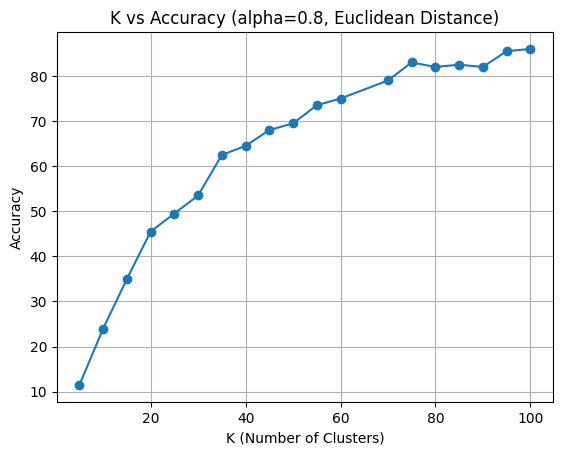

Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.


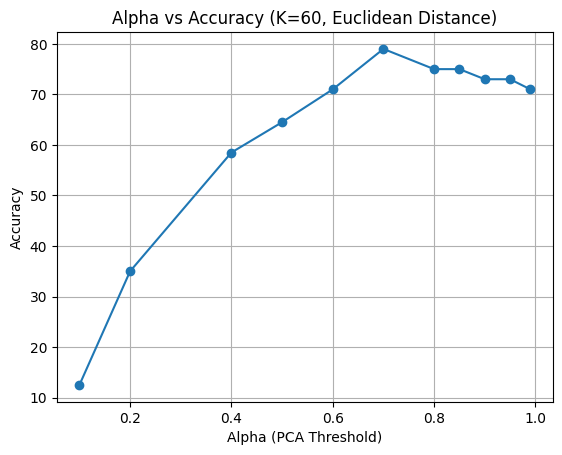

In [92]:
def kmean_analysis(X_train, y_train, X_test, y_test):
    k_values = [20,40,60]
    alpha_values = [0.8, 0.85, 0.9, 0.95]
    for alpha in alpha_values:
        for k in k_values:
            accuracy,_ = evaluate_model(X_train, y_train, X_test, y_test, n_clusters=k, alpha=alpha,random_initializations_limit=300, distance_strategy = EuclideanDistance) 
            print(f"Accuracy for K={k} and Alpha={alpha}: {accuracy:.2f}%")
        print("\n")    
    print("--------------------------------------------------")

    # Plot Accuracy vs K and Alpha
    k_values = [5, 10, 15, 20, 25, 30,35, 40,45, 50, 55, 60,70, 75, 80, 85, 90, 95, 100]
    alpha_values = [0.1,0.2,0.4,0.5,0.6,0.7,0.8, 0.85, 0.9, 0.95, 0.99]
    
    acc_vs_k = []
    for K in k_values:
        accuracy,_  = evaluate_model(X_train, y_train, X_test, y_test, n_clusters=K, alpha=0.8,random_initializations_limit=300, distance_strategy = EuclideanDistance) 
        acc_vs_k.append(accuracy)

    # Plot Accuracy vs K
    plt.figure()
    plt.plot(k_values, acc_vs_k, marker='o')
    plt.xlabel('K (Number of Clusters)')
    plt.ylabel('Accuracy')
    plt.title('K vs Accuracy (alpha=0.8, Euclidean Distance)')
    plt.grid(True)
    plt.show()

    acc_vs_alpha = []
    for alpha in alpha_values:
        accuracy,_  = evaluate_model(X_train, y_train, X_test, y_test, n_clusters = 60, alpha=alpha,random_initializations_limit=300, distance_strategy = EuclideanDistance)
        acc_vs_alpha.append(accuracy)

    # Plot Accuracy vs Alpha
    plt.figure()
    plt.plot(alpha_values, acc_vs_alpha, marker='o')
    plt.xlabel('Alpha (PCA Threshold)')
    plt.ylabel('Accuracy')
    plt.title('Alpha vs Accuracy (K=60, Euclidean Distance)')
    plt.grid(True)
    plt.show()

kmean_analysis(X_train, y_train, X_test, y_test)

Best model is k = 60 ,alpha = 0.80

4. As alpha increases from 0.1 to 0.8, the classification accuracy improves rapidly ,However beyond alpha = 0.8, the accuracy begins to decline slightly. This suggests that high alpha values may introduce noise or over-generalizatio

5. Higher K leads to better classification accuracy — more clusters allow the model to better capture complex structures in the data.

Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.
Loaded PCA data from cache.


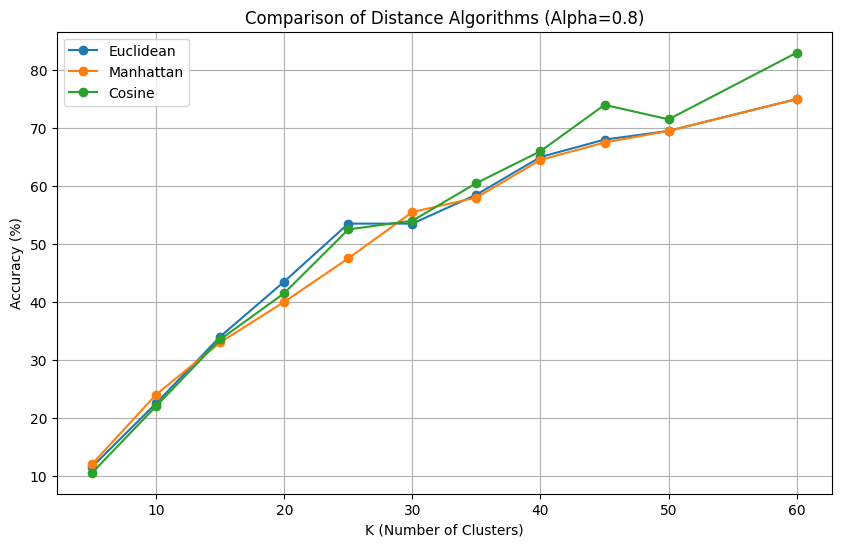

In [93]:
def compare_distance_algorithms(X_train, y_train, X_test, y_test, alpha=0.80):
   

    k_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60]  # Default K values

    # List of distance algorithms to compare
    distance_algorithms = [EuclideanDistance, ManhattanDistance, CosineDistance]
    algorithm_names = ["Euclidean", "Manhattan", "Cosine"]

    # Dictionary to store accuracies for each algorithm
    accuracies = {name: [] for name in algorithm_names}

    # Evaluate accuracy for each distance algorithm and each K value
    for distance_algorithm, name in zip(distance_algorithms, algorithm_names):
        for K in k_values:
            accuracy,_ = evaluate_model(
                X_train, y_train, X_test, y_test,
                n_clusters=K, alpha=alpha,
                random_initializations_limit=100,
                distance_strategy=distance_algorithm
            )
            accuracies[name].append(accuracy)

    
    plt.figure(figsize=(10, 6))
    for name in algorithm_names:
        plt.plot(k_values, accuracies[name], marker='o', label=name)

    plt.xlabel('K (Number of Clusters)')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Comparison of Distance Algorithms (Alpha={alpha})')
    plt.legend()
    plt.grid(True)
    plt.show()

compare_distance_algorithms(X_train, y_train, X_test, y_test, alpha=0.80)

Loaded PCA data from cache.
Accuracy: 75.00%
F1 Score (Weighted): 0.74
F1 Score (Macro): 0.74


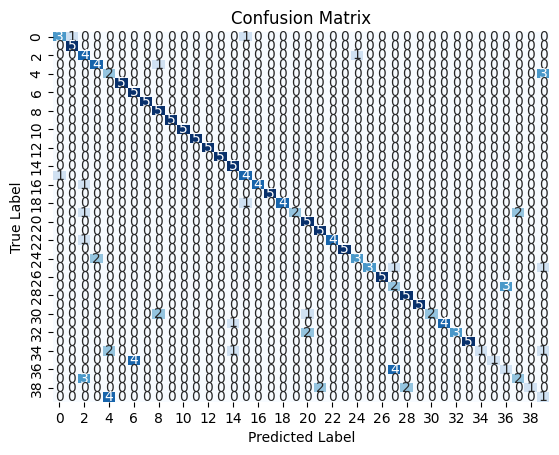

In [94]:
def evaluate_best_kmeans_model(X_train, y_train, X_test, y_test, k=60, alpha=0.80,distance_algorithm=EuclideanDistance):
    # Fit the KMeans model with the specified parameters
    accuracy, y_pred = evaluate_model(
        X_train, y_train, X_test, y_test,
        n_clusters=k, alpha=alpha,
        random_initializations_limit=100,
        distance_strategy=distance_algorithm
    )

    # Calculate F1 score
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"F1 Score (Weighted): {f1_weighted:.2f}")
    print(f"F1 Score (Macro): {f1_macro:.2f}")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    return accuracy, f1_weighted, f1_macro, cm
best_Kmeans_accuracy, best_f1_weighted, best_f1_macro, best_cm = evaluate_best_kmeans_model(X_train, y_train, X_test, y_test, k=60, alpha=0.80,distance_algorithm=EuclideanDistance)

# GMM Implementation
$\mathcal{N}(x;\mu,\Sigma)$ = $\frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}e^{-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)}$

In [95]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, reg_covar=1e-6, init_params='kmeans'):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.reg_covar = reg_covar  
        self.weights = None
        self.means = None
        self.covariances = None
        self.init_params = init_params  # 'kmeans' or 'random'

    def initialize_parameters(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_components) / self.n_components
        random_state = np.random.RandomState(self.random_state)
        if self.init_params == 'kmeans':
            from sklearn.cluster import KMeans
            kmeans = KMeans(n_clusters=self.n_components, random_state=random_state).fit(X)
            self.means = kmeans.cluster_centers_
        else:
            self.means = X[random_state.choice(n_samples, self.n_components, replace=False)]
        # Initialize covariance matrices with a small regularization term
        self.covariances = np.array([np.cov(X, rowvar=False) + self.reg_covar * np.eye(n_features) for _ in range(self.n_components)])

    def multivariate_gaussian(self, X, mean, covariance):
        n_features = X.shape[1]
        diff = X - mean
        cov_inv = np.linalg.pinv(covariance)  
        term = np.sum(diff @ cov_inv * diff, axis=1)
        sign, logdet = np.linalg.slogdet(covariance)
        if sign != 1:
            logdet = np.inf  
        log_prob = -0.5 * (n_features * np.log(2 * np.pi) + logdet + term)
        return log_prob  # Return the log probability (not the exp of it)

    def e_step(self, X):
        log_responsibilities = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            log_responsibilities[:, k] = np.log(self.weights[k]) + self.multivariate_gaussian(X, self.means[k], self.covariances[k])
        
        # Compute log-sum-exp for numerical stability
        log_responsibilities_max = np.max(log_responsibilities, axis=1, keepdims=True)
        log_responsibilities -= log_responsibilities_max  # Subtract max for numerical stability
        log_responsibilities_sum = np.log(np.sum(np.exp(log_responsibilities), axis=1, keepdims=True)) + log_responsibilities_max

        return log_responsibilities, log_responsibilities_sum

    def m_step(self, X, log_responsibilities):
        n_samples, n_features = X.shape
        log_responsibilities_exp = np.exp(log_responsibilities)  # Convert log back to probability
        NK = log_responsibilities_exp.sum(axis=0)
        # Avoid division by zero
        NK[NK == 0] = 1e-10  # Small value to prevent division by zero
        self.weights = NK / n_samples
        self.means = (log_responsibilities_exp.T @ X) / NK[:, np.newaxis]
        self.covariances = np.zeros((self.n_components, n_features, n_features))

        for k in range(self.n_components):
            diff = X - self.means[k]
            self.covariances[k] = (log_responsibilities_exp[:, k][:, np.newaxis] * diff).T @ diff / NK[k]
            # Regularization to ensure positive definiteness
            self.covariances[k] += self.reg_covar * np.eye(n_features)

    def fit(self, X):
        self.initialize_parameters(X)
        last_log_likelihood = None

        for i in range(self.max_iter):
            log_responsibilities, log_responsibilities_sum = self.e_step(X)
            self.m_step(X, log_responsibilities)

            log_likelihood = np.sum(log_responsibilities_sum)
            if last_log_likelihood is not None and abs(log_likelihood - last_log_likelihood) < self.tol:
                print(f"Converged after {i + 1} iterations.")
                break
            last_log_likelihood = log_likelihood

    def predict(self, X):
        n_samples = X.shape[0]
        log_probs = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            log_probs[:, k] = np.log(self.weights[k]) + self.multivariate_gaussian(X, self.means[k], self.covariances[k])
        
        return np.argmax(log_probs, axis=1)


In [96]:
def plot_log_likelihood(gmm):
    plt.figure(figsize=(8,5))
    plt.plot(gmm.log_likelihoods, marker='o')
    plt.title('Log-Likelihood over EM Iterations', fontsize=14)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Log-Likelihood', fontsize=12)
    plt.grid()
    plt.show()

In [97]:
def compute_clustering_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    best_mapping = dict(zip(col_ind, row_ind))
    y_pred_aligned = np.array([best_mapping.get(pred, pred) for pred in y_pred])

    acc = accuracy_score(y_true, y_pred_aligned)
    f1 = f1_score(y_true, y_pred_aligned, average='macro')
    return acc, f1, cm, y_pred_aligned

In [98]:
gmm_results = {}
best_random_model = None
best_kmeans_model = None

# Run GMM with different initializations and number of components
for init_params in ['random', 'kmeans']:
    for alpha, projections in pca_projections.items():
        X_train_pca = projections["train"]
        y_train_true = y_train

        for K in [20, 40, 60]:
            gmm = GMM(n_components=K, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, init_params=init_params)
            gmm.fit(X_train_pca)
            y_train_pred = gmm.predict(X_train_pca)
            accuracy, f1, cm, y_train_pred_aligned = compute_clustering_accuracy(y_train_true, y_train_pred)
            gmm_results[(init_params, alpha, K)] = {
                "gmm": gmm,
                "accuracy": accuracy,
                "f1_score": f1,
                "cm": cm
            }

            print(f"GMM with init_params={init_params}, alpha={alpha}, K={K}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")

# Create a DataFrame from the results
gmm_df = pd.DataFrame.from_dict(
    {k: {"init_params": k[0], "alpha": k[1], "K": k[2], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in gmm_results.items()},
    orient='index'
)

# Find the best models for random and kmeans++
best_random_model_key = gmm_df[gmm_df['init_params'] == 'random'].loc[gmm_df[gmm_df['init_params'] == 'random']['accuracy'].idxmax()]
best_kmeans_model_key = gmm_df[gmm_df['init_params'] == 'kmeans'].loc[gmm_df[gmm_df['init_params'] == 'kmeans']['accuracy'].idxmax()]

best_random_model = gmm_results[(best_random_model_key['init_params'], best_random_model_key['alpha'], best_random_model_key['K'])]['gmm']
best_kmeans_model = gmm_results[(best_kmeans_model_key['init_params'], best_kmeans_model_key['alpha'], best_kmeans_model_key['K'])]['gmm']

print("\nGMM Results DataFrame:")
print(gmm_df)

# Print the results for the best models
print("\nBest GMM Models:")
print(f"Best Random Model: Init Params: {best_random_model_key['init_params']}, Alpha: {best_random_model_key['alpha']}, K: {best_random_model_key['K']} With Accuracy: {best_random_model_key['accuracy']:.4f}, F1 Score: {best_random_model_key['f1_score']:.4f}")
print(f"Best KMeans++ Model: Init Params: {best_kmeans_model_key['init_params']}, Alpha: {best_kmeans_model_key['alpha']}, K: {best_kmeans_model_key['K']} With Accuracy: {best_kmeans_model_key['accuracy']:.4f}, F1 Score: {best_kmeans_model_key['f1_score']:.4f}")


Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=20: Accuracy=0.3750, F1 Score=0.2702
Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=40: Accuracy=0.5450, F1 Score=0.5142
Converged after 6 iterations.
GMM with init_params=random, alpha=0.8, K=60: Accuracy=0.5850, F1 Score=0.4242
Converged after 6 iterations.
GMM with init_params=random, alpha=0.85, K=20: Accuracy=0.3250, F1 Score=0.2435
Converged after 6 iterations.
GMM with init_params=random, alpha=0.85, K=40: Accuracy=0.4750, F1 Score=0.4490
Converged after 6 iterations.
GMM with init_params=random, alpha=0.85, K=60: Accuracy=0.5550, F1 Score=0.4047
Converged after 5 iterations.
GMM with init_params=random, alpha=0.9, K=20: Accuracy=0.2800, F1 Score=0.2259
Converged after 5 iterations.
GMM with init_params=random, alpha=0.9, K=40: Accuracy=0.3900, F1 Score=0.3699
Converged after 6 iterations.
GMM with init_params=random, alpha=0.9, K=60: Accuracy=0.4850, F1 Score=0.3530
Converged after 

/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 7 iterations.
GMM with init_params=kmeans, alpha=0.8, K=20: Accuracy=0.4550, F1 Score=0.3295


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 6 iterations.
GMM with init_params=kmeans, alpha=0.8, K=40: Accuracy=0.7400, F1 Score=0.7088


...

Converged after 5 iterations.
GMM with init_params=kmeans, alpha=0.95, K=20: Accuracy=0.4300, F1 Score=0.3127


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 4 iterations.
GMM with init_params=kmeans, alpha=0.95, K=40: Accuracy=0.6750, F1 Score=0.6389


/home/go3rany/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Converged after 4 iterations.
GMM with init_params=kmeans, alpha=0.95, K=60: Accuracy=0.7000, F1 Score=0.5175

GMM Results DataFrame:
               init_params  alpha   K  accuracy  f1_score
random 0.80 20      random   0.80  20     0.375  0.270153
            40      random   0.80  40     0.545  0.514250
            60      random   0.80  60     0.585  0.424162
       0.85 20      random   0.85  20     0.325  0.243488
            40      random   0.85  40     0.475  0.448975
            60      random   0.85  60     0.555  0.404666
       0.90 20      random   0.90  20     0.280  0.225864
            40      random   0.90  40     0.390  0.369869
            60      random   0.90  60     0.485  0.353028
       0.95 20      random   0.95  20     0.210  0.172909
            40      random   0.95  40     0.315  0.301311
            60      random   0.95  60     0.390  0.280443
kmeans 0.80 20      kmeans   0.80  20     0.455  0.329457
            40      kmeans   0.80  40     0.740  0.708


Tabulated Results for init_params=random:
alpha   0.80   0.85   0.90   0.95
K                                
20     0.375  0.325  0.280  0.210
40     0.545  0.475  0.390  0.315
60     0.585  0.555  0.485  0.390

Tabulated Results for init_params=kmeans:
alpha   0.80  0.85   0.90   0.95
K                               
20     0.455  0.45  0.470  0.430
40     0.740  0.71  0.675  0.675
60     0.715  0.73  0.720  0.700


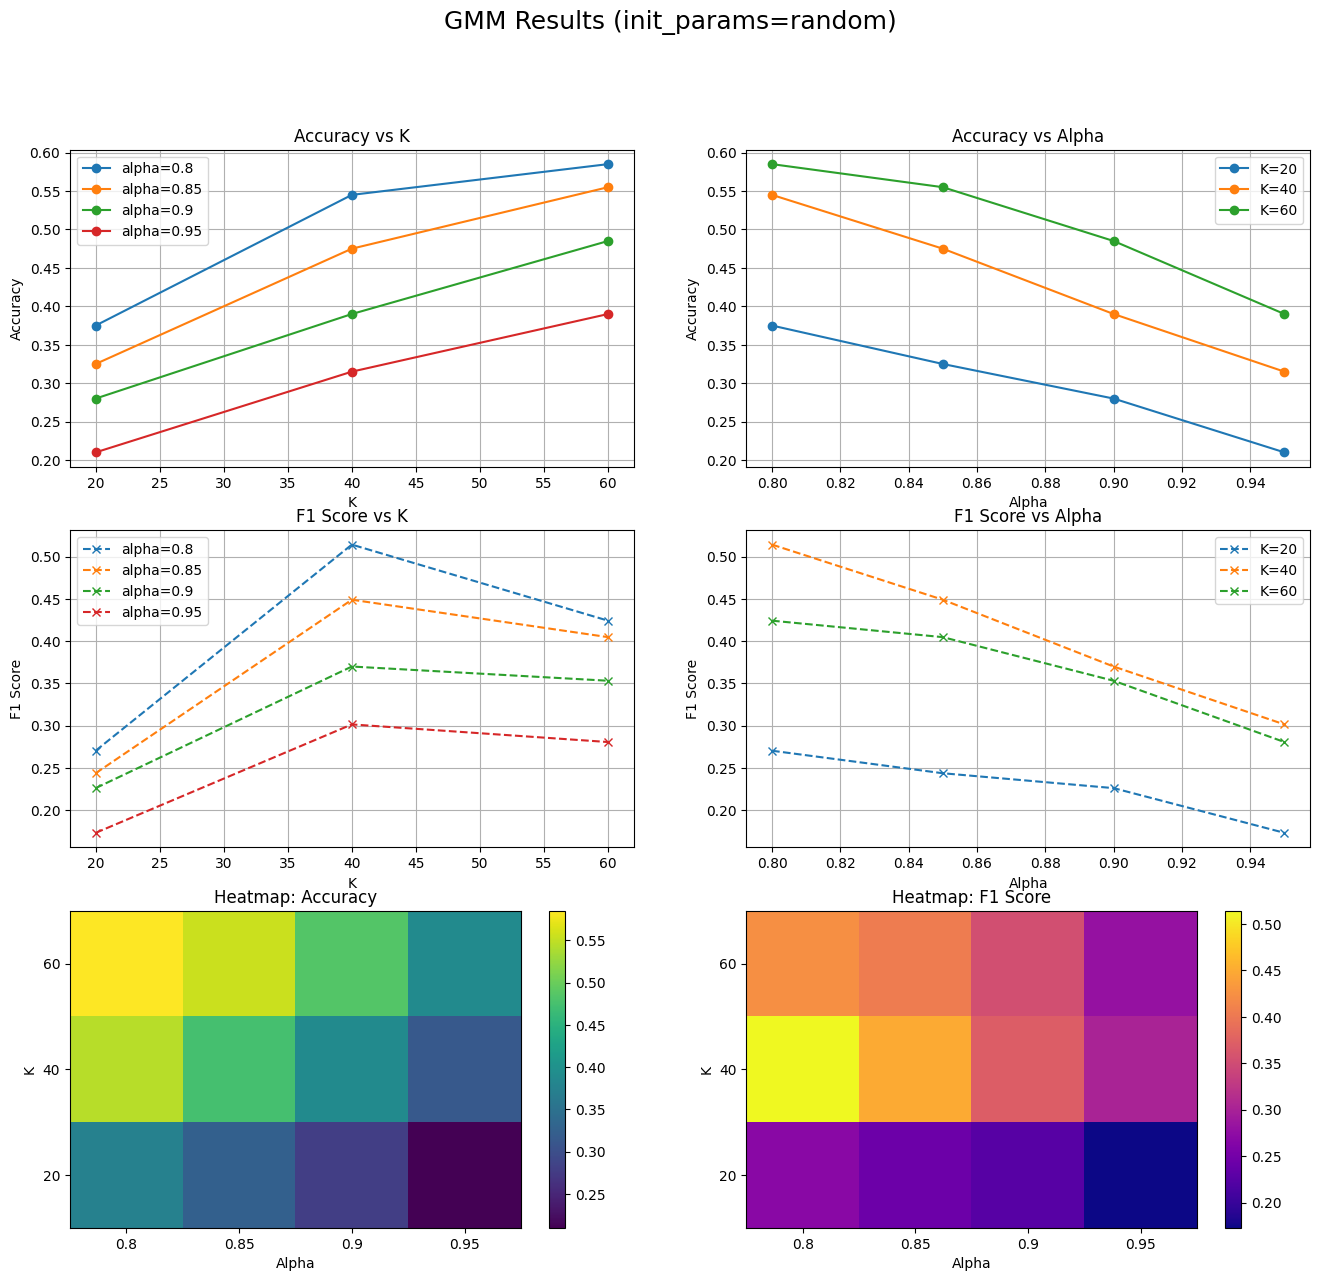

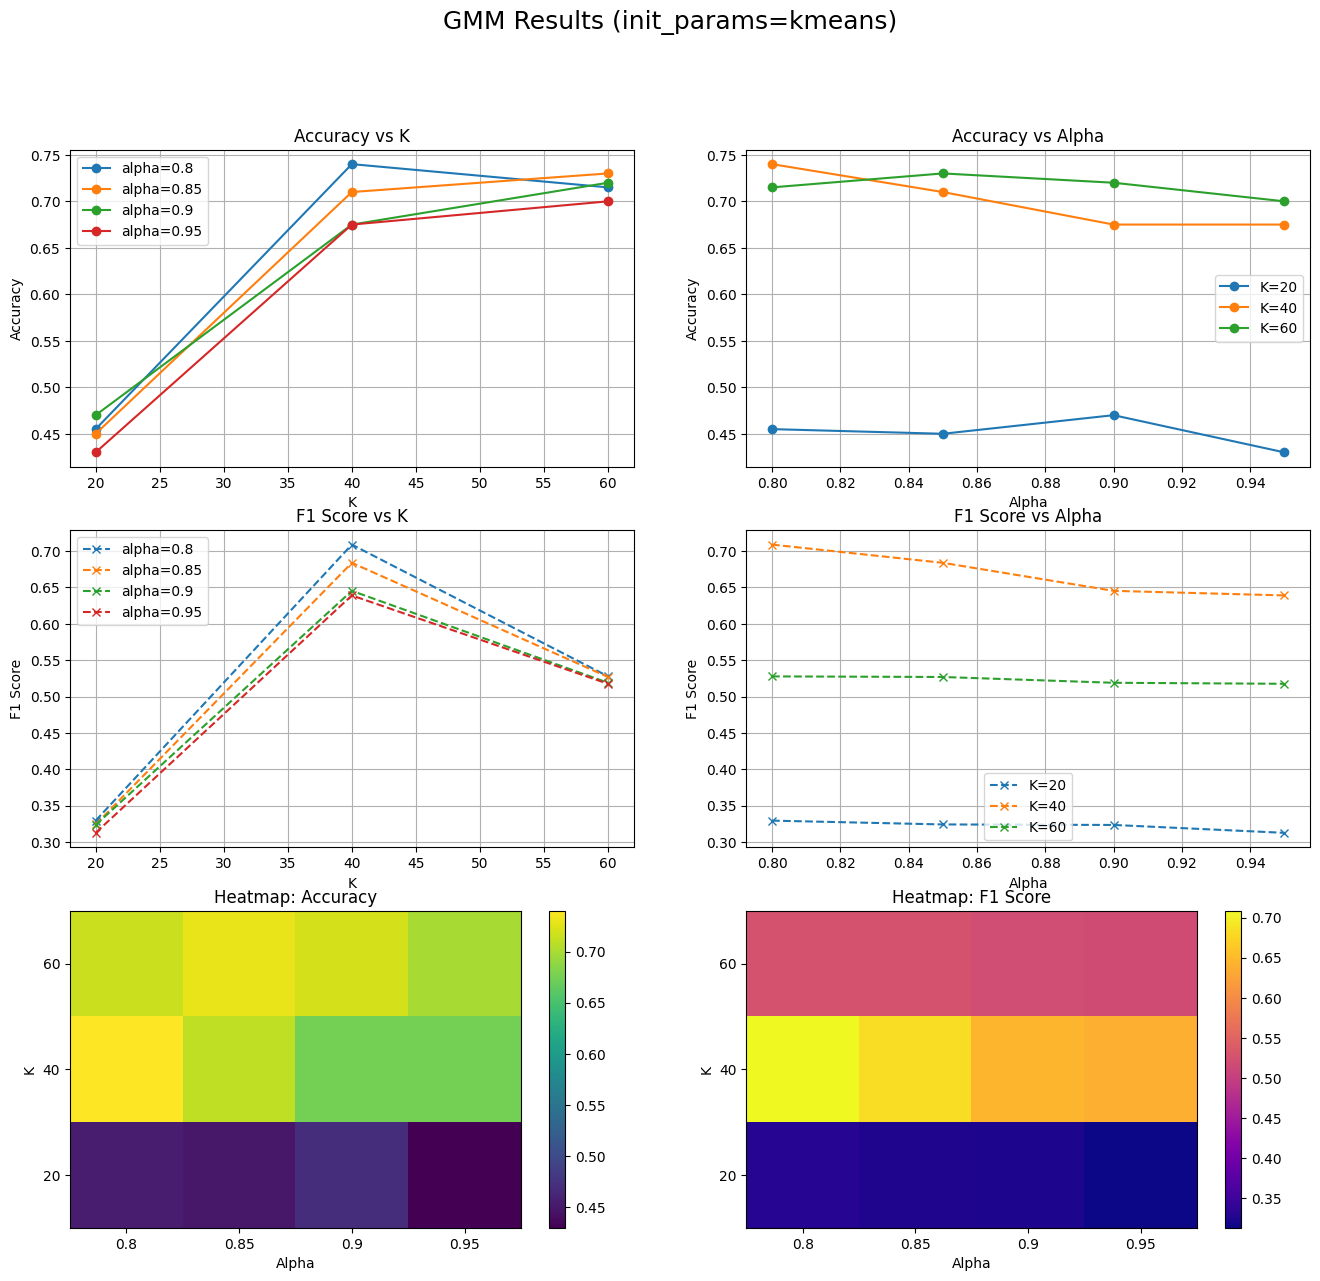

In [99]:
for init_param in gmm_df['init_params'].unique():
    df = gmm_df[gmm_df['init_params'] == init_param]

    fig, axs = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(f'GMM Results (init_params={init_param})', fontsize=18)

    # Plot 1: Accuracy vs K for each alpha
    ax = axs[0, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['accuracy'], marker='o', label=f'alpha={alpha}')
    ax.set_title('Accuracy vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 2: Accuracy vs Alpha for each K
    ax = axs[0, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['accuracy'], marker='o', label=f'K={K}')
    ax.set_title('Accuracy vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 3: F1 Score vs K for each alpha
    ax = axs[1, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['f1_score'], marker='x', linestyle='--', label=f'alpha={alpha}')
    ax.set_title('F1 Score vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 4: F1 Score vs Alpha for each K
    ax = axs[1, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['f1_score'], marker='x', linestyle='--', label=f'K={K}')
    ax.set_title('F1 Score vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 5: Heatmap of Accuracy
    ax = axs[2, 0]
    pivot_table = df.pivot(index='K', columns='alpha', values='accuracy')
    cax = ax.imshow(pivot_table, cmap='viridis', aspect='auto', origin='lower')
    ax.set_title('Heatmap: Accuracy')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table.columns)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)
    fig.colorbar(cax, ax=ax)

    # Plot 6: Heatmap of F1 Score
    ax = axs[2, 1]
    pivot_table_f1 = df.pivot(index='K', columns='alpha', values='f1_score')
    cax_f1 = ax.imshow(pivot_table_f1, cmap='plasma', aspect='auto', origin='lower')
    ax.set_title('Heatmap: F1 Score')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table_f1.columns)))
    ax.set_xticklabels(pivot_table_f1.columns)
    ax.set_yticks(range(len(pivot_table_f1.index)))
    ax.set_yticklabels(pivot_table_f1.index)
    fig.colorbar(cax_f1, ax=ax)
    
    # Tabulated print
    print(f"\nTabulated Results for init_params={init_param}:")
    print(df.pivot_table(index='K', columns='alpha', values='accuracy', aggfunc='mean'))



Evaluation on Test Set for Random model:
Test Accuracy: 0.5350
Test F1 Score: 0.3892

Evaluation on Test Set for KMeans++ model:
Test Accuracy: 0.6600
Test F1 Score: 0.6123


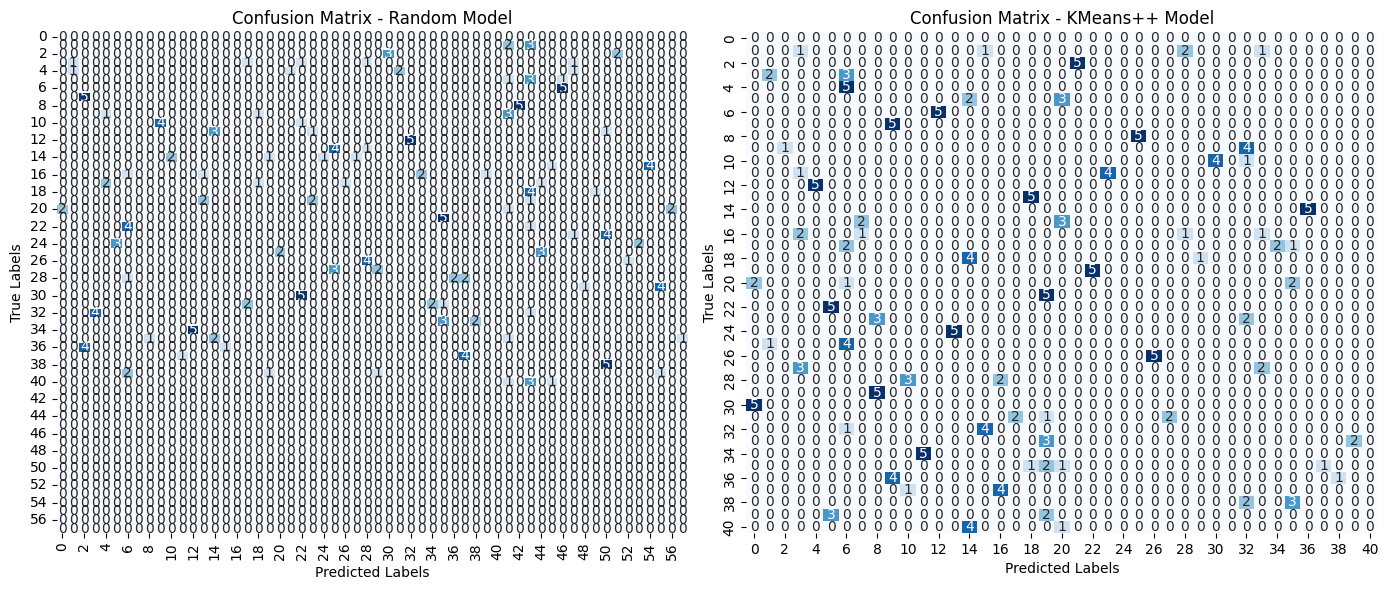

In [100]:
# Extract PCA projections for the test set
X_test_pca = pca_projections[best_random_model_key['alpha']]['test']
y_test_true = y_test

# Predict using the best Random model
y_test_pred_random = best_random_model.predict(X_test_pca)

# Evaluate on test data for Random model
test_acc_random, test_f1_random, test_cm_random, y_test_pred_aligned_random = compute_clustering_accuracy(y_test_true, y_test_pred_random)
print("\nEvaluation on Test Set for Random model:")
print(f"Test Accuracy: {test_acc_random:.4f}")
print(f"Test F1 Score: {test_f1_random:.4f}")

X_test_pca = pca_projections[best_kmeans_model_key['alpha']]['test']
# Predict using the best KMeans++ model
y_test_pred_kmeans = best_kmeans_model.predict(X_test_pca)

# Evaluate on test data for KMeans++ model
test_acc_kmeans, test_f1_kmeans, test_cm_kmeans, y_test_pred_aligned_kmeans = compute_clustering_accuracy(y_test_true, y_test_pred_kmeans)
print("\nEvaluation on Test Set for KMeans++ model:")
print(f"Test Accuracy: {test_acc_kmeans:.4f}")
print(f"Test F1 Score: {test_f1_kmeans:.4f}")

# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix for Random model
sns.heatmap(test_cm_random, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix - Random Model")
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Confusion Matrix for KMeans++ model
sns.heatmap(test_cm_kmeans, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix - KMeans++ Model")
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

3. **Relation between alpha and accuracy:**
For both random and kmeans initializations, as alpha increases, the accuracy tends to improve at lower values of K (e.g., K=20). However, for higher alpha values (like 0.95), the accuracy significantly drops, especially for larger K values (e.g., K=60).

4. **Relation between K and accuracy:**
Accuracy increases as K grows from 20 to 60 for both initialization methods, but the improvements are more pronounced when init_params='kmeans'. After reaching a certain K value (e.g., 40-60), the accuracy stabilizes or even drops with very high alpha values

In [ ]:
kmeans_results = {}
best_kmeans_results = None

for distance_algorithm in [EuclideanDistance, ManhattanDistance, CosineDistance]:
    for alpha, projections in pca_projections.items():
        X_train_pca = projections["train"]
        y_train_true = y_train
        for K in [20, 40, 60]:
            kmeans = KMeans(n_clusters=K, random_initializations_limit=100, distance_strategy=distance_algorithm)
            kmeans.fit(X_train_pca)
            kmeans.assign_labels_to_clusters(y_train_true)
            y_train_pred = kmeans.kmeans_predict(X_train_pca)
            accuracy = accuracy_score(y_train_true, y_train_pred)
            f1 = f1_score(y_train_true, y_train_pred, average='macro')
            cm = confusion_matrix(y_train_true, y_train_pred)
            kmeans_results[(distance_algorithm.__name__, alpha, K)] = {
                "kmeans": kmeans,
                "accuracy": accuracy,
                "f1_score": f1,
                "cm": cm
            }
        
            print(f"KMeans with distance_algorithm={distance_algorithm.__name__}, alpha={alpha}, K={K}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")

# Create a DataFrame from the results
kmeans_df = pd.DataFrame.from_dict(
    {k: {"distance_algorithm": k[0], "alpha": k[1], "K": k[2], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in kmeans_results.items()},
    orient='index'
)

# Print the results DataFrame
print("\nKMeans Results DataFrame:")
print(kmeans_df)

# Find the best models for each distance algorithm
best_models = {}
for distance_algorithm in kmeans_df['distance_algorithm'].unique():
    df = kmeans_df[kmeans_df['distance_algorithm'] == distance_algorithm]
    best_model_key = df.loc[df['accuracy'].idxmax()]
    best_models[distance_algorithm] = {
        "model": kmeans_results[(best_model_key['distance_algorithm'], best_model_key['alpha'], best_model_key['K'])]['kmeans'],
        "accuracy": best_model_key['accuracy'],
        "f1_score": best_model_key['f1_score']
    }
    print(f"\nBest KMeans Model for {distance_algorithm}:")
    print(f"Distance Algorithm: {best_model_key['distance_algorithm']}, Alpha: {best_model_key['alpha']}, K: {best_model_key['K']} With Accuracy: {best_model_key['accuracy']:.4f}, F1 Score: {best_model_key['f1_score']:.4f}")

KMeans with distance_algorithm=EuclideanDistance, alpha=0.8, K=20: Accuracy=0.4500, F1 Score=0.3297
KMeans with distance_algorithm=EuclideanDistance, alpha=0.8, K=40: Accuracy=0.7200, F1 Score=0.6771
KMeans with distance_algorithm=EuclideanDistance, alpha=0.8, K=60: Accuracy=0.8350, F1 Score=0.8317
KMeans with distance_algorithm=EuclideanDistance, alpha=0.85, K=20: Accuracy=0.4400, F1 Score=0.3287
KMeans with distance_algorithm=EuclideanDistance, alpha=0.85, K=40: Accuracy=0.6950, F1 Score=0.6284
KMeans with distance_algorithm=EuclideanDistance, alpha=0.85, K=60: Accuracy=0.8150, F1 Score=0.8087
KMeans with distance_algorithm=EuclideanDistance, alpha=0.9, K=20: Accuracy=0.4500, F1 Score=0.3315
KMeans with distance_algorithm=EuclideanDistance, alpha=0.9, K=40: Accuracy=0.6850, F1 Score=0.6344
KMeans with distance_algorithm=EuclideanDistance, alpha=0.9, K=60: Accuracy=0.8050, F1 Score=0.7971
KMeans with distance_algorithm=EuclideanDistance, alpha=0.95, K=20: Accuracy=0.4700, F1 Score=0.3

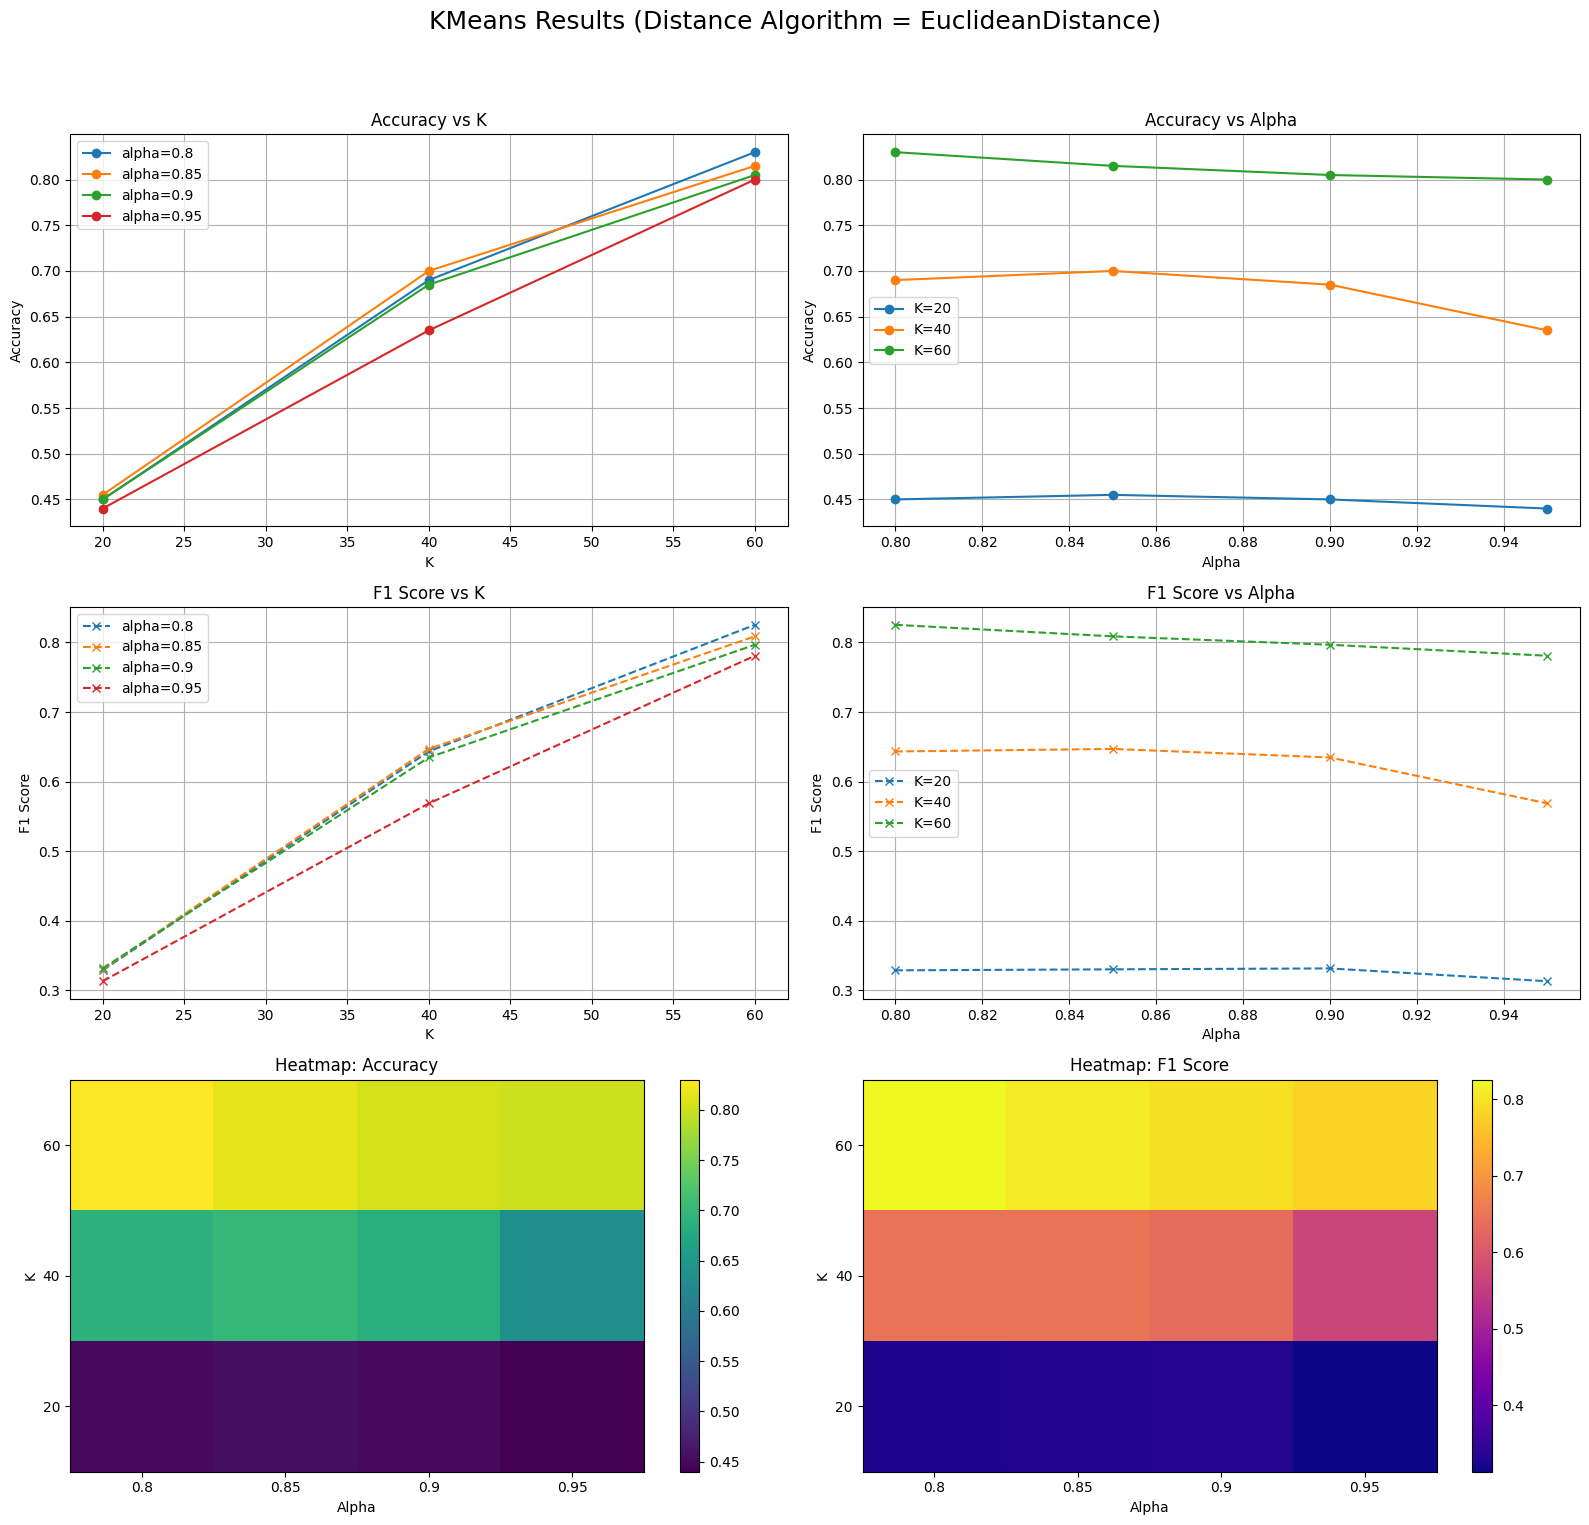


Tabulated Accuracy Results (Distance Algorithm = EuclideanDistance):
alpha  0.80   0.85   0.90   0.95
K                               
20     0.45  0.455  0.450  0.440
40     0.69  0.700  0.685  0.635
60     0.83  0.815  0.805  0.800


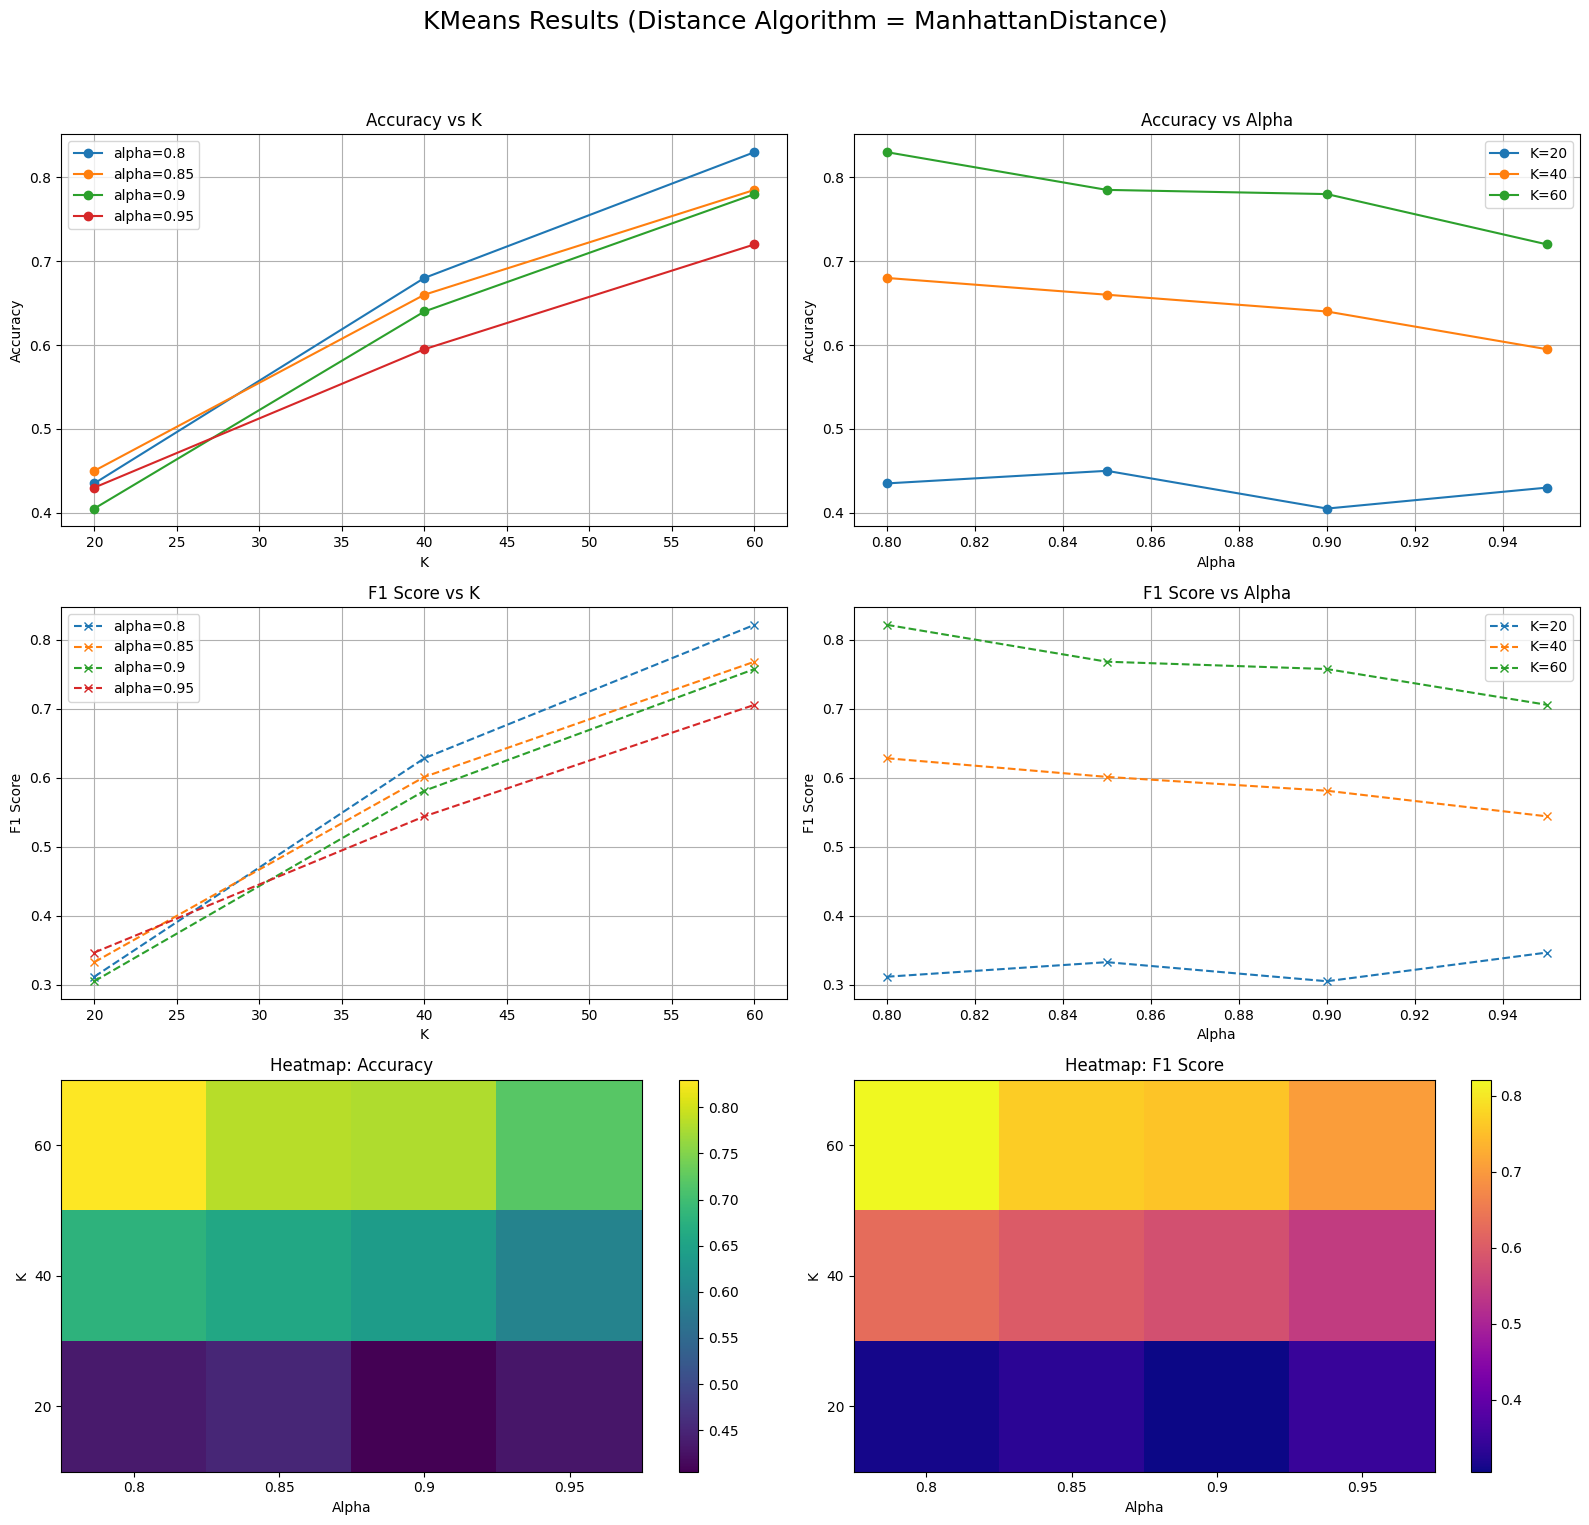


Tabulated Accuracy Results (Distance Algorithm = ManhattanDistance):
alpha   0.80   0.85   0.90   0.95
K                                
20     0.435  0.450  0.405  0.430
40     0.680  0.660  0.640  0.595
60     0.830  0.785  0.780  0.720


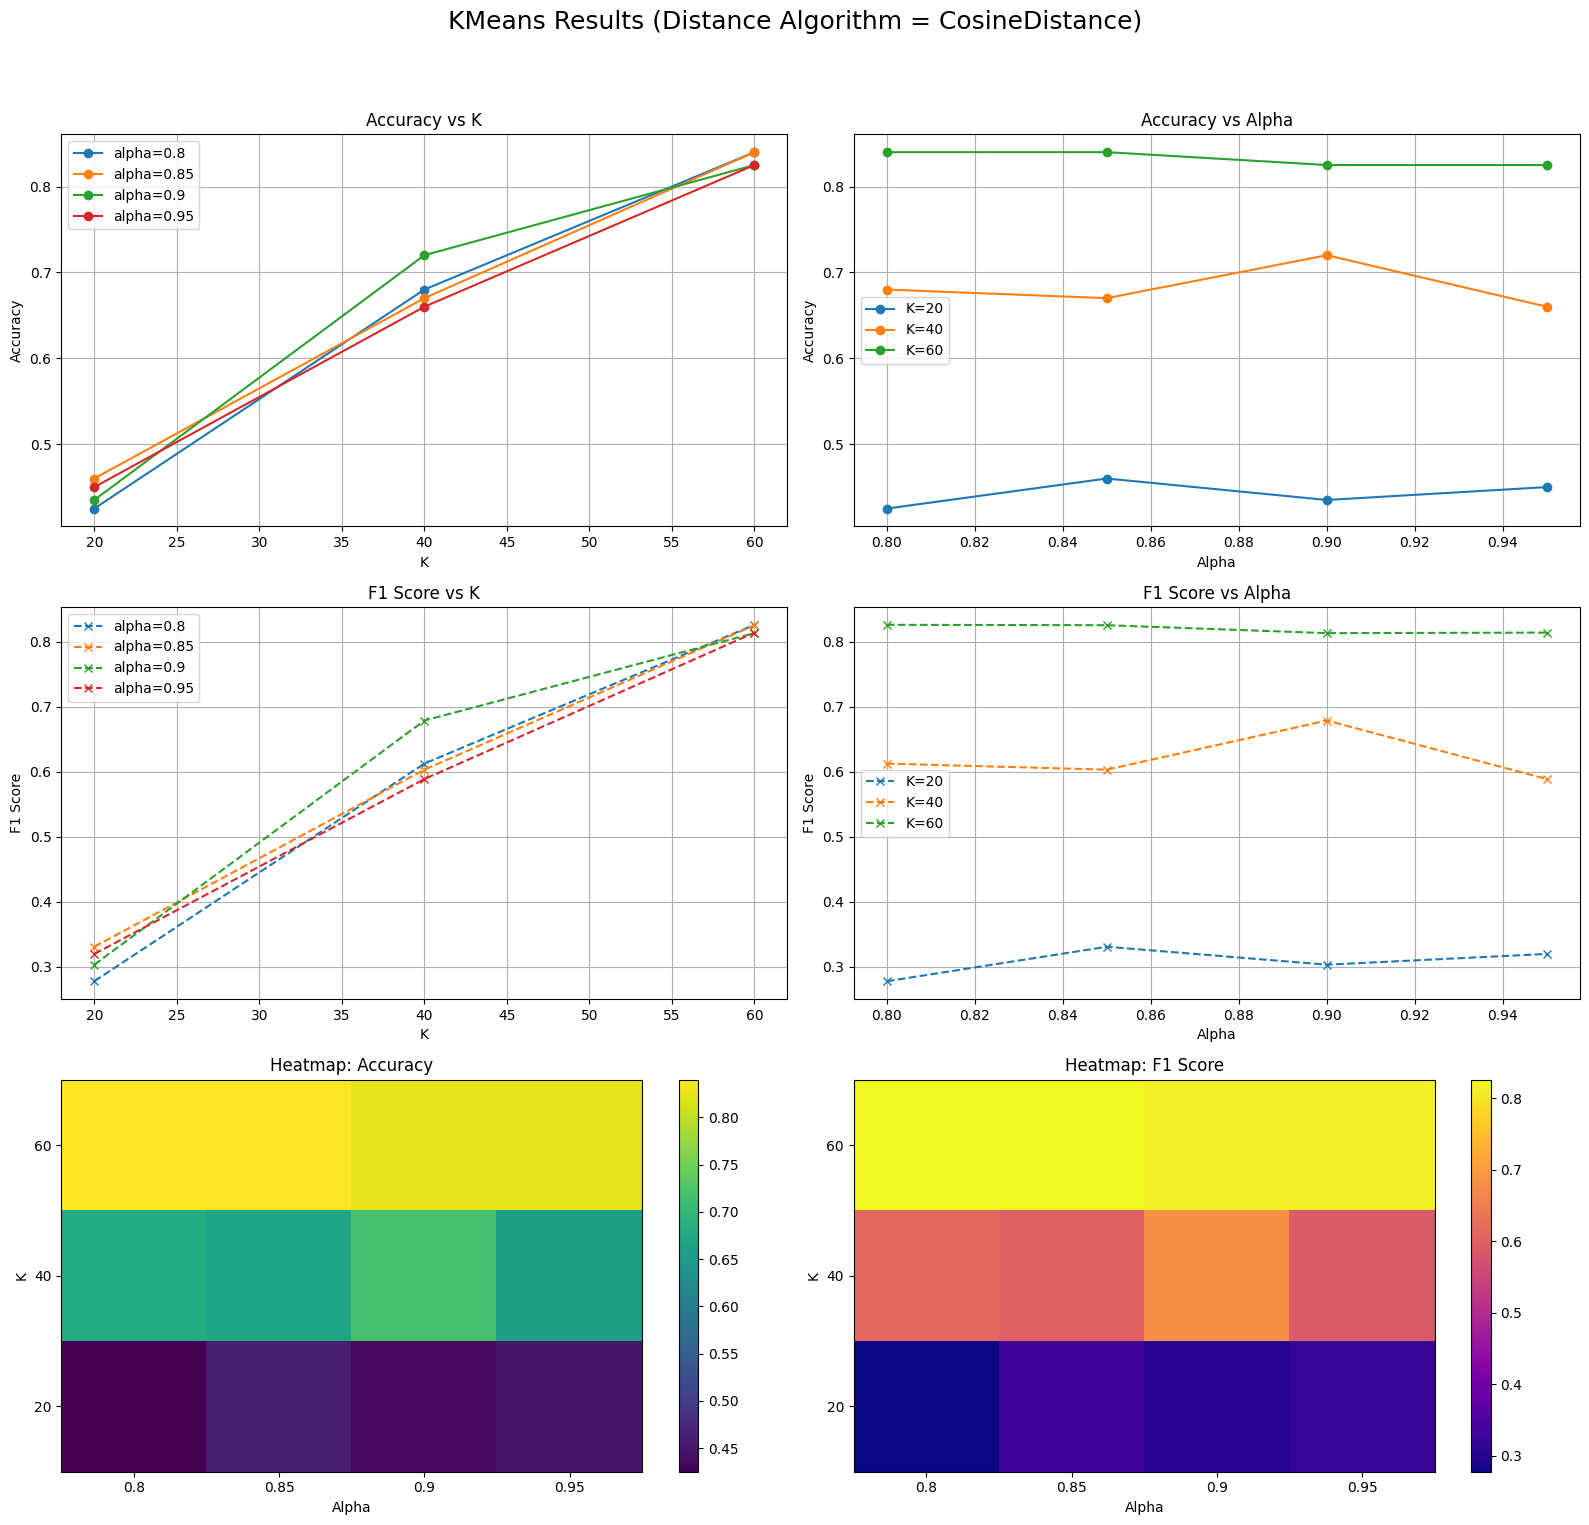


Tabulated Accuracy Results (Distance Algorithm = CosineDistance):
alpha   0.80  0.85   0.90   0.95
K                               
20     0.425  0.46  0.435  0.450
40     0.680  0.67  0.720  0.660
60     0.840  0.84  0.825  0.825


In [ ]:
for distance_algorithm in kmeans_df['distance_algorithm'].unique():
    df = kmeans_df[kmeans_df['distance_algorithm'] == distance_algorithm]

    fig, axs = plt.subplots(3, 2, figsize=(16, 16))
    fig.suptitle(f'KMeans Results (Distance Algorithm = {distance_algorithm})', fontsize=18)

    # Plot 1: Accuracy vs K for each alpha
    ax = axs[0, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['accuracy'], marker='o', label=f'alpha={alpha}')
    ax.set_title('Accuracy vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 2: Accuracy vs Alpha for each K
    ax = axs[0, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['accuracy'], marker='o', label=f'K={K}')
    ax.set_title('Accuracy vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Accuracy')
    ax.grid(True)
    ax.legend()

    # Plot 3: F1 Score vs K for each alpha
    ax = axs[1, 0]
    for alpha in sorted(df['alpha'].unique()):
        df_alpha = df[df['alpha'] == alpha]
        ax.plot(df_alpha['K'], df_alpha['f1_score'], marker='x', linestyle='--', label=f'alpha={alpha}')
    ax.set_title('F1 Score vs K')
    ax.set_xlabel('K')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 4: F1 Score vs Alpha for each K
    ax = axs[1, 1]
    for K in sorted(df['K'].unique()):
        df_K = df[df['K'] == K]
        ax.plot(df_K['alpha'], df_K['f1_score'], marker='x', linestyle='--', label=f'K={K}')
    ax.set_title('F1 Score vs Alpha')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('F1 Score')
    ax.grid(True)
    ax.legend()

    # Plot 5: Heatmap of Accuracy
    ax = axs[2, 0]
    pivot_table = df.pivot(index='K', columns='alpha', values='accuracy')
    cax = ax.imshow(pivot_table, cmap='viridis', aspect='auto', origin='lower')
    ax.set_title('Heatmap: Accuracy')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table.columns)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticks(range(len(pivot_table.index)))
    ax.set_yticklabels(pivot_table.index)
    fig.colorbar(cax, ax=ax)

    # Plot 6: Heatmap of F1 Score
    ax = axs[2, 1]
    pivot_table_f1 = df.pivot(index='K', columns='alpha', values='f1_score')
    cax_f1 = ax.imshow(pivot_table_f1, cmap='plasma', aspect='auto', origin='lower')
    ax.set_title('Heatmap: F1 Score')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('K')
    ax.set_xticks(range(len(pivot_table_f1.columns)))
    ax.set_xticklabels(pivot_table_f1.columns)
    ax.set_yticks(range(len(pivot_table_f1.index)))
    ax.set_yticklabels(pivot_table_f1.index)
    fig.colorbar(cax_f1, ax=ax)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Tabulated print of Accuracy
    print(f"\nTabulated Accuracy Results (Distance Algorithm = {distance_algorithm}):")
    print(df.pivot_table(index='K', columns='alpha', values='accuracy', aggfunc='mean').round(4))


# KMeans Vs GMM

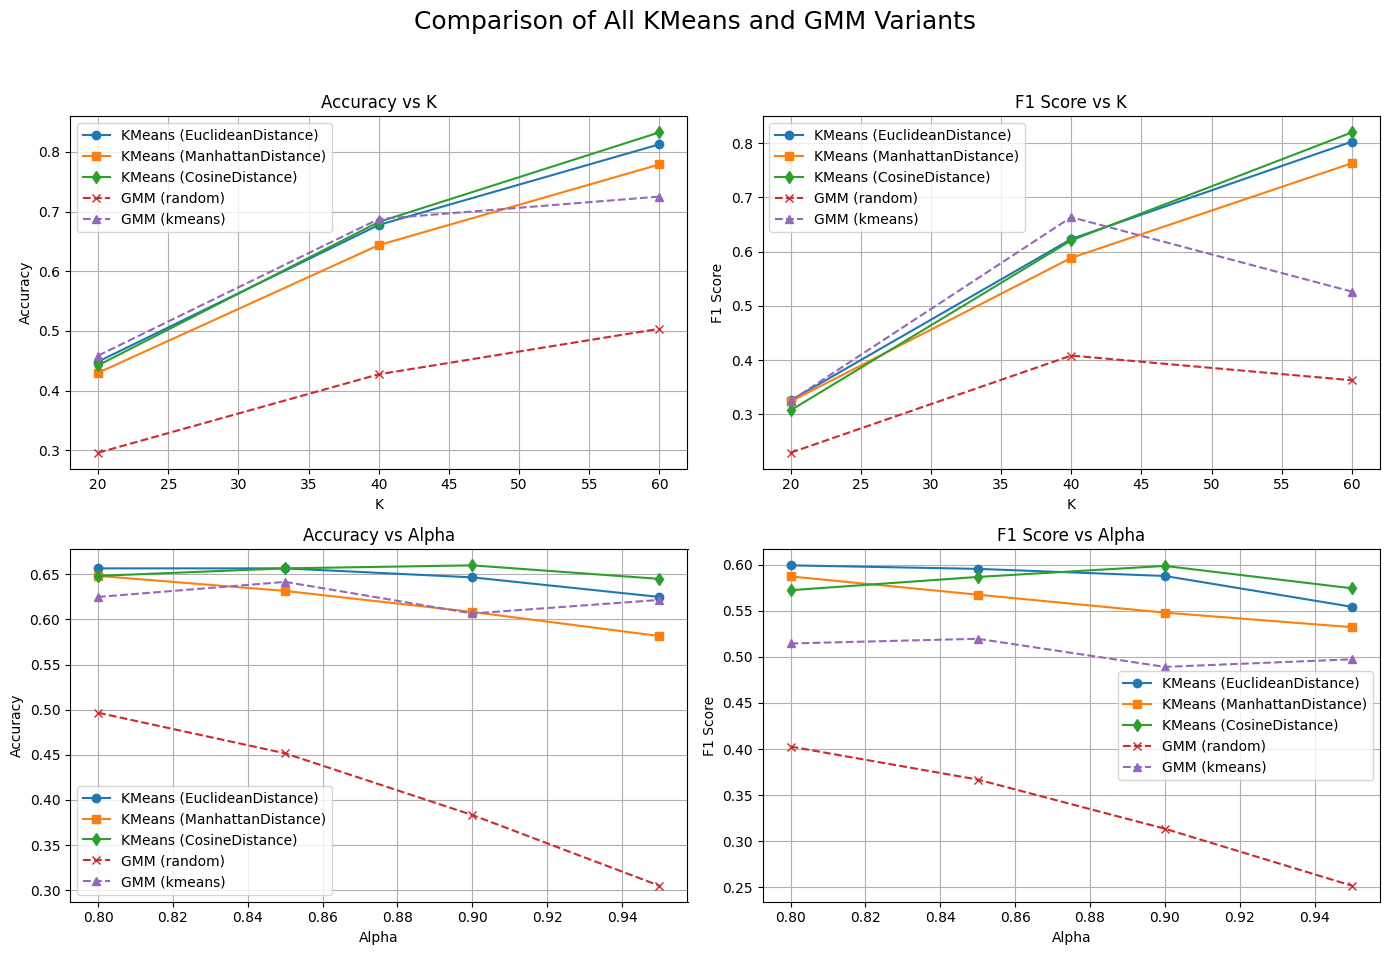


--- Best Models by Accuracy ---
KMeans (Euclidean): Best at K=60, alpha=0.8, accuracy=0.8300
KMeans (Manhattan): Best at K=60, alpha=0.8, accuracy=0.8300
KMeans (Cosine): Best at K=60, alpha=0.8, accuracy=0.8400
GMM (Random): Best at K=60, alpha=0.8, accuracy=0.5800
GMM (Kmeans): Best at K=40, alpha=0.85, accuracy=0.7450

--- Best Models by F1 Score ---
KMeans (Euclidean): Best at K=60, alpha=0.8, f1_score=0.8253
KMeans (Manhattan): Best at K=60, alpha=0.8, f1_score=0.8214
KMeans (Cosine): Best at K=60, alpha=0.8, f1_score=0.8263
GMM (Random): Best at K=40, alpha=0.8, f1_score=0.5238
GMM (Kmeans): Best at K=40, alpha=0.85, f1_score=0.7156


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparison of All KMeans and GMM Variants', fontsize=18)

markers = {
    'EuclideanDistance': 'o',
    'ManhattanDistance': 's',
    'CosineDistance': 'd',
    'random': 'x',
    'kmeans': '^'
}

# Plot 1: Accuracy vs K
ax = axs[0, 0]
for dist in ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance']:
    df = kmeans_df[kmeans_df['distance_algorithm'] == dist]
    grouped = df.groupby('K')['accuracy'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[dist], label=f'KMeans ({dist})')
for init in ['random', 'kmeans']:
    df = gmm_df[gmm_df['init_params'] == init]
    grouped = df.groupby('K')['accuracy'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[init], linestyle='--', label=f'GMM ({init})')
ax.set_title('Accuracy vs K')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.grid(True)
ax.legend()

# Plot 2: F1 Score vs K
ax = axs[0, 1]
for dist in ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance']:
    df = kmeans_df[kmeans_df['distance_algorithm'] == dist]
    grouped = df.groupby('K')['f1_score'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[dist], label=f'KMeans ({dist})')
for init in ['random', 'kmeans']:
    df = gmm_df[gmm_df['init_params'] == init]
    grouped = df.groupby('K')['f1_score'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[init], linestyle='--', label=f'GMM ({init})')
ax.set_title('F1 Score vs K')
ax.set_xlabel('K')
ax.set_ylabel('F1 Score')
ax.grid(True)
ax.legend()

# Plot 3: Accuracy vs Alpha
ax = axs[1, 0]
for dist in ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance']:
    df = kmeans_df[kmeans_df['distance_algorithm'] == dist]
    grouped = df.groupby('alpha')['accuracy'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[dist], label=f'KMeans ({dist})')
for init in ['random', 'kmeans']:
    df = gmm_df[gmm_df['init_params'] == init]
    grouped = df.groupby('alpha')['accuracy'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[init], linestyle='--', label=f'GMM ({init})')
ax.set_title('Accuracy vs Alpha')
ax.set_xlabel('Alpha')
ax.set_ylabel('Accuracy')
ax.grid(True)
ax.legend()

# Plot 4: F1 Score vs Alpha
ax = axs[1, 1]
for dist in ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance']:
    df = kmeans_df[kmeans_df['distance_algorithm'] == dist]
    grouped = df.groupby('alpha')['f1_score'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[dist], label=f'KMeans ({dist})')
for init in ['random', 'kmeans']:
    df = gmm_df[gmm_df['init_params'] == init]
    grouped = df.groupby('alpha')['f1_score'].mean()
    ax.plot(grouped.index, grouped.values, marker=markers[init], linestyle='--', label=f'GMM ({init})')
ax.set_title('F1 Score vs Alpha')
ax.set_xlabel('Alpha')
ax.set_ylabel('F1 Score')
ax.grid(True)
ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

configs = [
    {'df': kmeans_df, 'col': 'distance_algorithm',
     'values': ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance'],
     'label_fmt': 'KMeans ({})'},
    
    {'df': gmm_df, 'col': 'init_params',
     'values': ['random', 'kmeans'],
     'label_fmt': 'GMM ({})'}
]

metrics = ['accuracy', 'f1_score']

for metric in metrics:
    print(f"\n--- Best Models by {metric.replace('_', ' ').title()} ---")
    for config in configs:
        df = config['df']
        for value in config['values']:
            label = config['label_fmt'].format(value.replace('Distance', '').title())
            filtered_df = df[df[config['col']] == value]
            
            best_idx = filtered_df[metric].idxmax()
            best_row = filtered_df.loc[best_idx]

            best_k = best_row['K']
            best_alpha = best_row['alpha']
            best_val = best_row[metric]

            print(f"{label}: Best at K={best_k}, alpha={best_alpha}, {metric}={best_val:.4f}")


# Autoencoder Implementation

In [ ]:
class Autoencoder:
    def __init__(self, input_dim, 
                 encoding_dim=100, 
                 hidden_layers=[512, 256],
                 learning_rate=1e-3):
        """
        Autoencoder constructor.

        Args:
            input_dim (int): Size of input feature vector (10304 for ORL).
            encoding_dim (int): Size of bottleneck layer.
            hidden_layers (list of int): Sizes of encoder hidden layers (decoder will mirror them).
            learning_rate (float): Learning rate for optimizer.
        """
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        
        self.autoencoder = None
        self.encoder = None
        self.history = None
        
        self.build_model()

    def build_model(self):
        input_img = Input(shape=(self.input_dim,))
        x = input_img

        # Encoder hidden layers
        for units in self.hidden_layers:
            x = Dense(units, activation='relu')(x)
        
        # Bottleneck
        encoded = Dense(self.encoding_dim, activation='relu')(x)

        # Decoder hidden layers (mirror of encoder)
        x = encoded
        for units in reversed(self.hidden_layers):
            x = Dense(units, activation='relu')(x)
        
        # Output layer
        decoded = Dense(self.input_dim, activation='sigmoid')(x)
        
        # Build models
        self.autoencoder = Model(input_img, decoded)
        self.encoder = Model(input_img, encoded)
        
        self.autoencoder.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')

    def fit(self, X_train, X_val=None, epochs=50, batch_size=32, shuffle=True):
        if X_val is not None:
            validation_data = (X_val, X_val)
        else:
            validation_data = None
        
        self.history = self.autoencoder.fit(
            X_train, X_train,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=shuffle,
            validation_data=validation_data,
            verbose=1
        )

    def encode(self, X):
        return self.encoder.predict(X)
    
    def decode(self, encoded_X):
        return self.autoencoder.predict(encoded_X)

    def reconstruct(self, X):
        return self.autoencoder.predict(X)
    
    def plot_reconstructions(self, X, n_faces=5, img_shape=(112, 92)):
        indices = np.random.choice(X.shape[0], size=n_faces, replace=False)
        X_encoded = self.encode(X)
        X_decoded = self.decode(X)

        fig, axes = plt.subplots(2, n_faces, figsize=(3 * n_faces, 6))
        fig.suptitle("Original (Top) vs Autoencoder Reconstructed (Bottom)", fontsize=16, weight='bold')

        for i, idx in enumerate(indices):
            # Original
            axes[0, i].imshow(X[idx].reshape(img_shape), cmap='gray')
            axes[0, i].axis('off')
            
            # Reconstructed
            axes[1, i].imshow(X_decoded[idx].reshape(img_shape), cmap='gray')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()


In [ ]:
# Normalize
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Initialize Autoencoder
autoenc = Autoencoder(
    input_dim=10304,
    encoding_dim=100,
    hidden_layers=[512, 256],
    learning_rate=1e-3
)

# Train
autoenc.fit(X_train_norm, X_val=X_test_norm, epochs=50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - loss: 0.0380 - val_loss: 0.0252
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0253 - val_loss: 0.0247
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.0239 - val_loss: 0.0232
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0237 - val_loss: 0.0226
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0221 - val_loss: 0.0210
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.0202 - val_loss: 0.0196
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0196 - val_loss: 0.0193
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0194 - val_loss: 0.0207
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0196 - val_loss: 0.0193
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0186 - val_loss: 0.0182
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0177 - val_loss: 0.0173
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0173 - val_lo

In [ ]:
# Encode training and test data
encoded_train = autoenc.encode(X_train_norm)
encoded_test = autoenc.encode(X_test_norm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


# Visualization of reconstructed faces

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


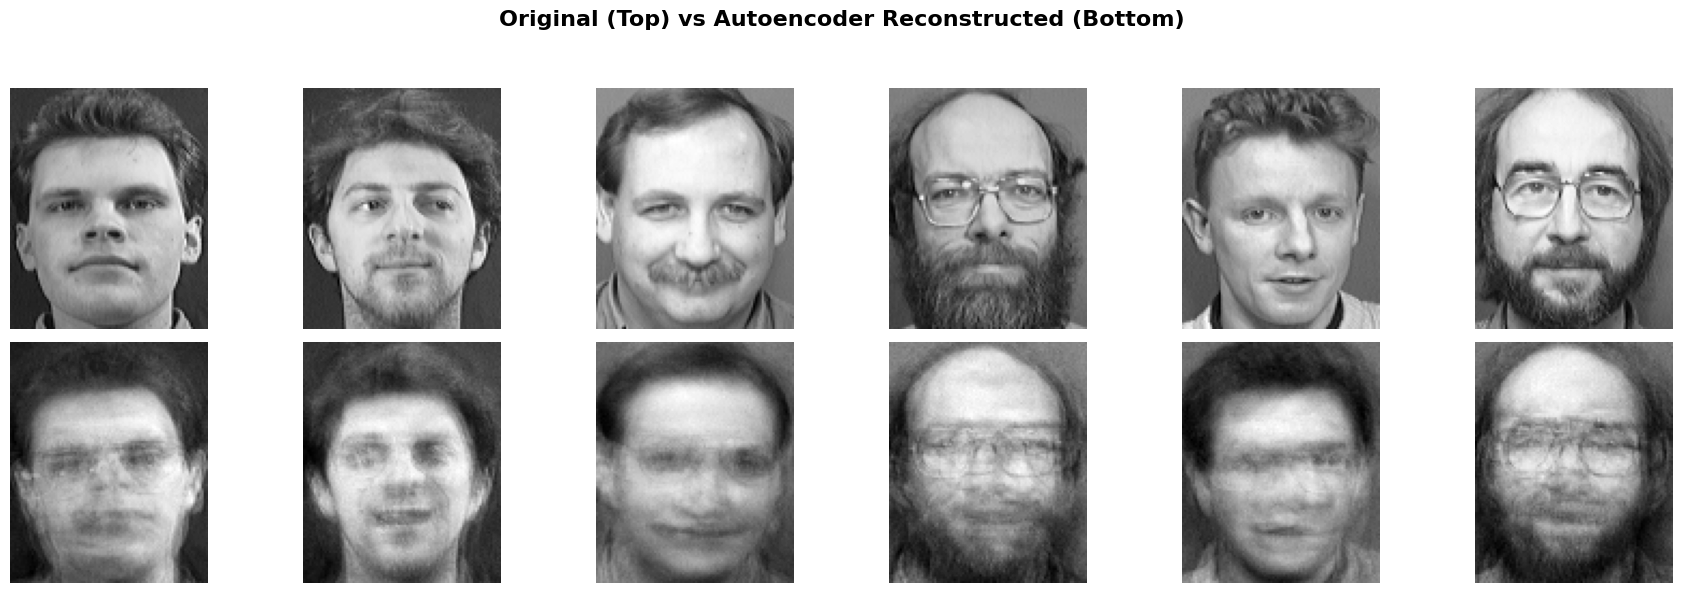

In [ ]:
autoenc.plot_reconstructions(X_test_norm, n_faces=6)

# KMeans Clustering

KMeans with K=20, Distance=EuclideanDistance: Accuracy=0.4200, F1 Score=0.2986
KMeans with K=40, Distance=EuclideanDistance: Accuracy=0.6550, F1 Score=0.6098
KMeans with K=60, Distance=EuclideanDistance: Accuracy=0.7550, F1 Score=0.7313
KMeans with K=20, Distance=ManhattanDistance: Accuracy=0.4400, F1 Score=0.3061
KMeans with K=40, Distance=ManhattanDistance: Accuracy=0.6400, F1 Score=0.5635
KMeans with K=60, Distance=ManhattanDistance: Accuracy=0.7500, F1 Score=0.7265
KMeans with K=20, Distance=CosineDistance: Accuracy=0.4300, F1 Score=0.3024
KMeans with K=40, Distance=CosineDistance: Accuracy=0.6250, F1 Score=0.5789
KMeans with K=60, Distance=CosineDistance: Accuracy=0.7700, F1 Score=0.7640

Best Autoencoder KMeans Model:
K: 60, Distance: CosineDistance With Accuracy: 0.7700, F1 Score: 0.7640


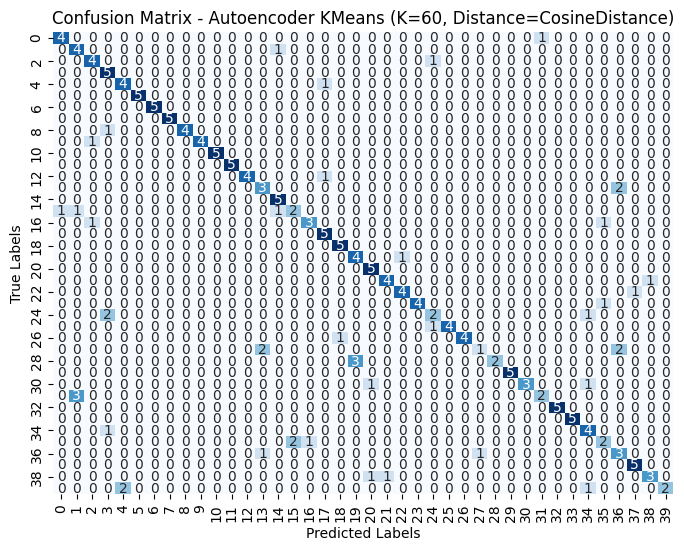

In [ ]:
kmeans_autoenc_results = {}
for distance_algorithm in [EuclideanDistance, ManhattanDistance, CosineDistance]:
    for K in [20, 40, 60]:
        kmeans = KMeans(n_clusters=K, random_initializations_limit=100, distance_strategy=distance_algorithm)
        kmeans.fit(encoded_train)
        kmeans.assign_labels_to_clusters(y_train)
        y_train_pred = kmeans.kmeans_predict(encoded_train)
        accuracy = accuracy_score(y_train, y_train_pred)
        f1 = f1_score(y_train, y_train_pred, average='macro')
        cm = confusion_matrix(y_train, y_train_pred)
        kmeans_autoenc_results[(K, distance_algorithm.__name__)] = {
            "accuracy": accuracy,
            "f1_score": f1,
            "cm": cm
        }
        print(f"KMeans with K={K}, Distance={distance_algorithm.__name__}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")
    
# Create a DataFrame from the results
kmeans_autoenc_df = pd.DataFrame.from_dict(
    {k: {"K": k[0], "Distance": k[1], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in kmeans_autoenc_results.items()},
    orient='index'
)
# Find the best model
best_autoenc_model_key = kmeans_autoenc_df.loc[kmeans_autoenc_df['accuracy'].idxmax()]
best_autoenc_model = kmeans_autoenc_results[(best_autoenc_model_key['K'], best_autoenc_model_key['Distance'])]
print("\nBest Autoencoder KMeans Model:")
print(f"K: {best_autoenc_model_key['K']}, Distance: {best_autoenc_model_key['Distance']} With Accuracy: {best_autoenc_model_key['accuracy']:.4f}, F1 Score: {best_autoenc_model_key['f1_score']:.4f}")

# Plot confusion matrix for the best Autoencoder KMeans model
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(best_autoenc_model['cm'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title(f"Confusion Matrix - Autoencoder KMeans (K={best_autoenc_model_key['K']}, Distance={best_autoenc_model_key['Distance']})")
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.show()

# GMM Clustering

Converged after 5 iterations.
GMM with init_params=random, K=20: Accuracy=0.3100, F1 Score=0.2263
Converged after 5 iterations.
GMM with init_params=random, K=40: Accuracy=0.4300, F1 Score=0.4005
Converged after 8 iterations.
GMM with init_params=random, K=60: Accuracy=0.5200, F1 Score=0.3811
Converged after 5 iterations.
GMM with init_params=kmeans, K=20: Accuracy=0.4300, F1 Score=0.3073
Converged after 6 iterations.
GMM with init_params=kmeans, K=40: Accuracy=0.6600, F1 Score=0.6250
Converged after 5 iterations.
GMM with init_params=kmeans, K=60: Accuracy=0.6200, F1 Score=0.4556

GMM Autoencoder Results DataFrame:
          init_params   K  accuracy  f1_score
random 20      random  20      0.31  0.226332
       40      random  40      0.43  0.400486
       60      random  60      0.52  0.381136
kmeans 20      kmeans  20      0.43  0.307311
       40      kmeans  40      0.66  0.624997
       60      kmeans  60      0.62  0.455635

Best GMM Autoencoder Models:
Best Random Model: Init 

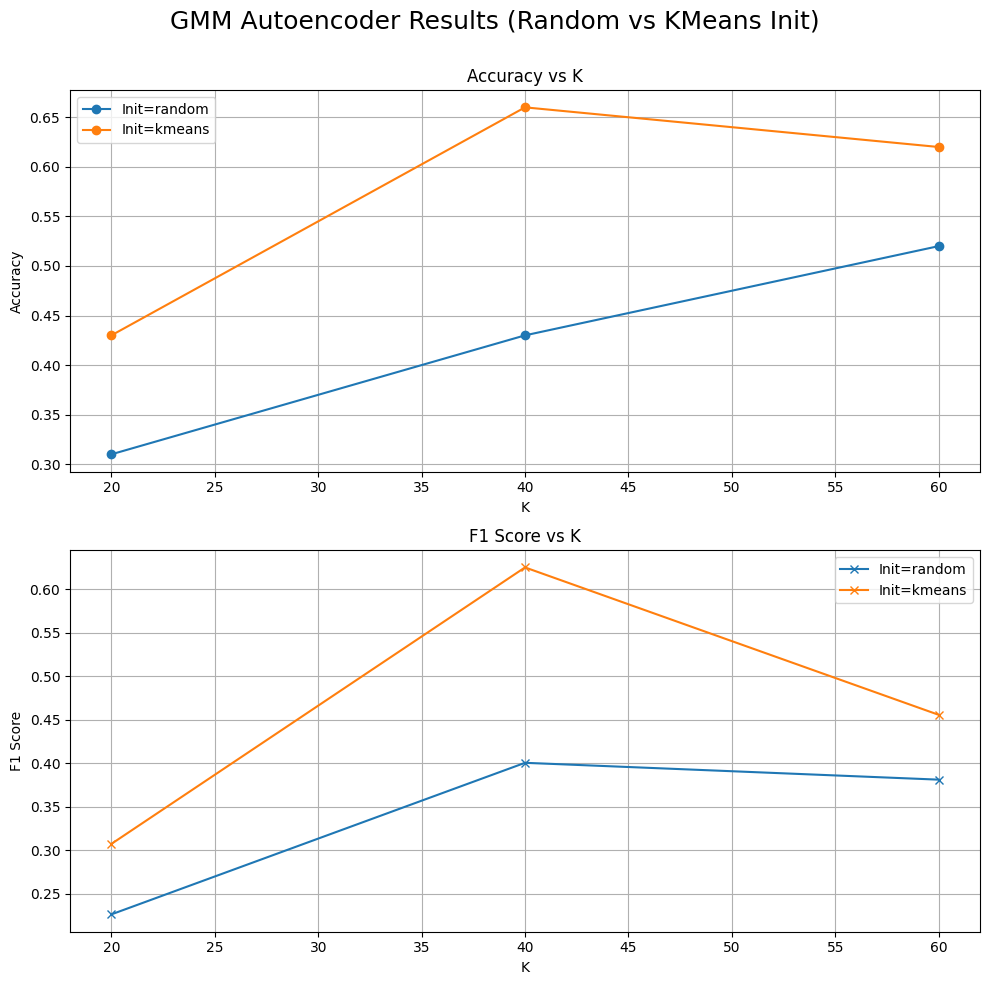


Tabulated Results for GMM Autoencoder:
init_params  kmeans  random
K                          
20             0.43    0.31
40             0.66    0.43
60             0.62    0.52


In [ ]:
gmm_autoenc_results = {}
for init_params in ['random', 'kmeans']:
    for K in [20, 40, 60]:
        gmm = GMM(n_components=K, max_iter=100, tol=1e-6, random_state=RANDOM_SEED, init_params=init_params)
        gmm.fit(encoded_train)
        y_train_pred = gmm.predict(encoded_train)
        accuracy, f1, cm, y_train_pred_aligned = compute_clustering_accuracy(y_train, y_train_pred)
        gmm_autoenc_results[(init_params, K)] = {
            "gmm": gmm,
            "accuracy": accuracy,
            "f1_score": f1,
            "cm": cm
        }

        print(f"GMM with init_params={init_params}, K={K}: Accuracy={accuracy:.4f}, F1 Score={f1:.4f}")
gmm_autoenc_df = pd.DataFrame.from_dict(
    {k: {"init_params": k[0], "K": k[1], "accuracy": v["accuracy"], "f1_score": v["f1_score"]} for k, v in gmm_autoenc_results.items()},
    orient='index'
)
print("\nGMM Autoencoder Results DataFrame:")
print(gmm_autoenc_df)

print("\nBest GMM Autoencoder Models:")
best_gmm_autoenc_random_key = gmm_autoenc_df[gmm_autoenc_df['init_params'] == 'random'].loc[
    gmm_autoenc_df[gmm_autoenc_df['init_params'] == 'random']['accuracy'].idxmax()
]
best_gmm_autoenc_kmeans_key = gmm_autoenc_df[gmm_autoenc_df['init_params'] == 'kmeans'].loc[
    gmm_autoenc_df[gmm_autoenc_df['init_params'] == 'kmeans']['accuracy'].idxmax()
]

best_gmm_autoenc_random = gmm_autoenc_results[('random', best_gmm_autoenc_random_key['K'])]['gmm']
best_gmm_autoenc_kmeans = gmm_autoenc_results[('kmeans', best_gmm_autoenc_kmeans_key['K'])]['gmm']
print(f"Best Random Model: Init Params: {best_gmm_autoenc_random_key['init_params']}, K: {best_gmm_autoenc_random_key['K']} With Accuracy: {best_gmm_autoenc_random_key['accuracy']:.4f}, F1 Score: {best_gmm_autoenc_random_key['f1_score']:.4f}")
print(f"Best KMeans Model: Init Params: {best_gmm_autoenc_kmeans_key['init_params']}, K: {best_gmm_autoenc_kmeans_key['K']} With Accuracy: {best_gmm_autoenc_kmeans_key['accuracy']:.4f}, F1 Score: {best_gmm_autoenc_kmeans_key['f1_score']:.4f}")

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle('GMM Autoencoder Results (Random vs KMeans Init)', fontsize=18)

# Accuracy vs K
ax = axs[0]
for init_param in gmm_autoenc_df['init_params'].unique():
    df = gmm_autoenc_df[gmm_autoenc_df['init_params'] == init_param]
    ax.plot(df['K'], df['accuracy'], marker='o', label=f'Init={init_param}')
ax.set_title('Accuracy vs K')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.grid(True)
ax.legend()

# F1 Score vs K
ax = axs[1]
for init_param in gmm_autoenc_df['init_params'].unique():
    df = gmm_autoenc_df[gmm_autoenc_df['init_params'] == init_param]
    ax.plot(df['K'], df['f1_score'], marker='x', label=f'Init={init_param}')
ax.set_title('F1 Score vs K')
ax.set_xlabel('K')
ax.set_ylabel('F1 Score')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Tabulated print
print("\nTabulated Results for GMM Autoencoder:")
print(gmm_autoenc_df.pivot_table(index='K', columns='init_params', values='accuracy', aggfunc='mean'))


Autoencoder GMM Test Set Evaluation:
Random Init -> K=60, Accuracy: 0.4400, F1 Score: 0.3255
KMeans Init -> K=40, Accuracy: 0.5800, F1 Score: 0.5388


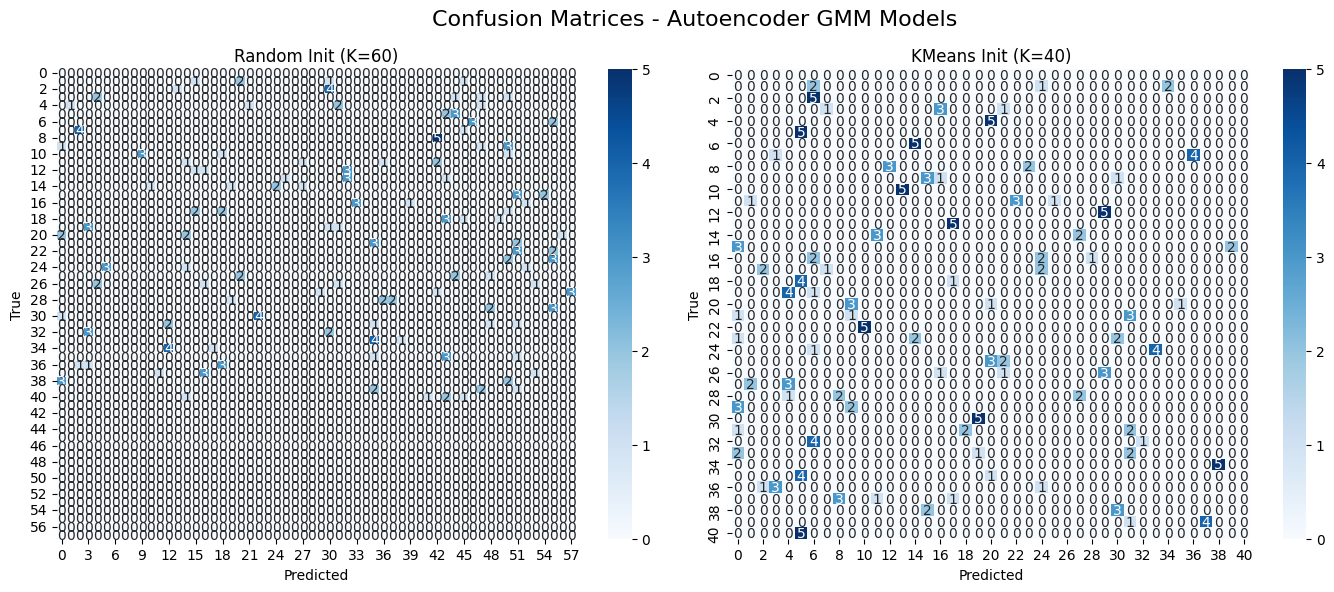


Tabulated Results for GMM Autoencoder:
init_params  kmeans  random
K                          
20             0.43    0.31
40             0.66    0.43
60             0.62    0.52


In [ ]:
y_test_pred_random = best_gmm_autoenc_random.predict(encoded_test)
acc_random, f1_random, cm_random, y_test_pred_random_aligned = compute_clustering_accuracy(y_test, y_test_pred_random)

y_test_pred_kmeans = best_gmm_autoenc_kmeans.predict(encoded_test)
acc_kmeans, f1_kmeans, cm_kmeans, y_test_pred_kmeans_aligned = compute_clustering_accuracy(y_test, y_test_pred_kmeans)

# Step 3: Print evaluation metrics
print("\nAutoencoder GMM Test Set Evaluation:")
print(f"Random Init -> K={best_gmm_autoenc_random_key['K']}, Accuracy: {acc_random:.4f}, F1 Score: {f1_random:.4f}")
print(f"KMeans Init -> K={best_gmm_autoenc_kmeans_key['K']}, Accuracy: {acc_kmeans:.4f}, F1 Score: {f1_kmeans:.4f}")

# Step 4: Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices - Autoencoder GMM Models', fontsize=16)

# Random Init Confusion Matrix
sns.heatmap(cm_random, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Random Init (K={best_gmm_autoenc_random_key["K"]})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# KMeans Init Confusion Matrix
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'KMeans Init (K={best_gmm_autoenc_kmeans_key["K"]})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# Optional: Tabulated results for reference
print("\nTabulated Results for GMM Autoencoder:")
print(gmm_autoenc_df.pivot_table(index='K', columns='init_params', values='accuracy', aggfunc='mean'))


--- Best Models by Accuracy ---
GMM Autoencoder (random) Init: Best model at K=60, accuracy=0.5200
GMM Autoencoder (kmeans) Init: Best model at K=40, accuracy=0.6600
KMeans Autoencoder (Euclidean) Distance: Best model at K=60, accuracy=0.7550
KMeans Autoencoder (Manhattan) Distance: Best model at K=60, accuracy=0.7500
KMeans Autoencoder (Cosine) Distance: Best model at K=60, accuracy=0.7700

--- Best Models by F1 Score ---
GMM Autoencoder (random) Init: Best model at K=40, f1_score=0.4005
GMM Autoencoder (kmeans) Init: Best model at K=40, f1_score=0.6250
KMeans Autoencoder (Euclidean) Distance: Best model at K=60, f1_score=0.7313
KMeans Autoencoder (Manhattan) Distance: Best model at K=60, f1_score=0.7265
KMeans Autoencoder (Cosine) Distance: Best model at K=60, f1_score=0.7640


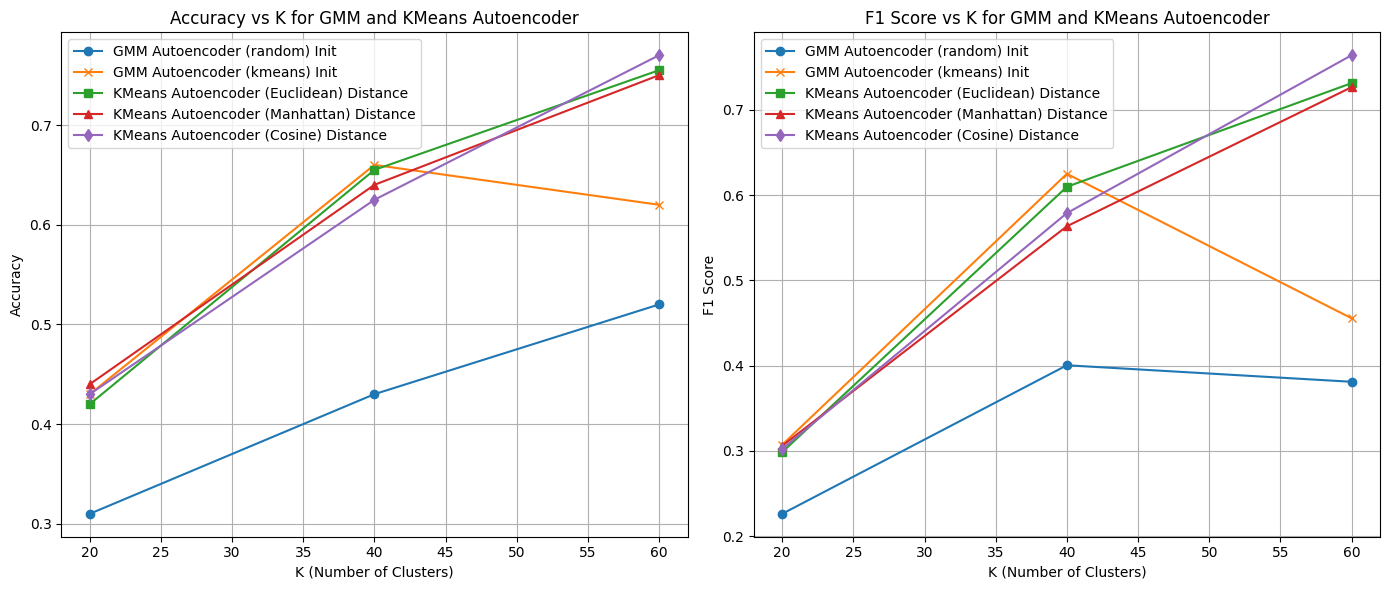

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Define plotting configurations
plot_configs = [
    {
        'df': gmm_autoenc_df,
        'filter_col': 'init_params',
        'values': ['random', 'kmeans'],
        'label_fmt': 'GMM Autoencoder ({}) Init',
        'markers': ['o', 'x']
    },
    {
        'df': kmeans_autoenc_df,
        'filter_col': 'Distance',
        'values': ['EuclideanDistance', 'ManhattanDistance', 'CosineDistance'],
        'label_fmt': 'KMeans Autoencoder ({}) Distance',
        'markers': ['s', '^', 'd']
    }
]

metrics = ['accuracy', 'f1_score']
titles = ['Accuracy vs K for GMM and KMeans Autoencoder', 'F1 Score vs K for GMM and KMeans Autoencoder']

# Loop over the two metrics
for ax, metric, title in zip(axes, metrics, titles):
    print(f"\n--- Best Models by {metric.replace('_', ' ').title()} ---")
    for config in plot_configs:
        df = config['df']
        for value, marker in zip(config['values'], config['markers']):
            filtered_df = df[df[config['filter_col']] == value]
            label = config['label_fmt'].format(value.replace('Distance', ''))

            # Plot the line
            ax.plot(filtered_df['K'], filtered_df[metric], marker=marker, label=label)

            # Find and print best model
            best_idx = filtered_df[metric].idxmax()
            best_k = filtered_df.loc[best_idx, 'K']
            best_val = filtered_df.loc[best_idx, metric]
            print(f"{label}: Best model at K={best_k}, {metric}={best_val:.4f}")

    ax.set_xlabel('K (Number of Clusters)')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()
